<a href="https://colab.research.google.com/github/rafaellopesdesa/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_5_Hybrid_NormalizingFlow_DensityRatio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Exercise 5 — Hybrid normalizing-flow and density-ratio estimation

Exercise 4 estimated the signal and background densities with two independent normalizing flows. That is flexible, but the likelihood ultimately depends on the much more demanding ratio $p_S(x)/p_B(x)$, so small unrelated flow errors can be amplified.

Here we combine the two approaches introduced earlier in the workshop:

1. use the same learned PRESEL selection as Exercise 4 to improve $S/B$;
2. build an equal-mixture reference density after PRESEL,
   $$p_{\rm ref}(x)=\tfrac12 p_S(x)+\tfrac12 p_B(x);$$
3. train **one** normalizing flow for $p_{\rm ref}$;
4. sample five million unweighted reference events from that flow;
5. use four-model Exercise 2 classifier ensembles to estimate
   $$r_S(x)=\frac{p_S(x)}{p_{\rm ref}(x)},\qquad
     r_B(x)=\frac{p_B(x)}{p_{\rm ref}(x)};$$
6. reconstruct the component densities as

   $$\hat p_S(x)=\hat p_{\rm ref}(x)\hat r_S(x),\qquad
     \hat p_B(x)=\hat p_{\rm ref}(x)\hat r_B(x);$$
7. repeat the extended-likelihood fit and toy study from Exercise 4.

The reference flow provides flexible generation and an explicit density. The classifiers only need to learn ratios against a reference that covers signal and background equally. In the profile likelihood, common errors in $p_{\rm ref}$ are independent of $\mu$ and cancel, while the precision-critical information is learned discriminatively.


In [25]:
## ============================================================================
# Google Colab setup — run me first.  Safe to re-run; a no-op off Colab.
# ============================================================================
import os, sys

# --- config -----------------------------------------------------------------
REPO_URL = "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git"  # package + tutorial helpers
BRANCH   = "ml4hep_school_tutorial"
N_BKG, N_SIG = 100_000_000, 20_000_000     # Colab-sized dataset (raise for less MC noise in the fit)
USE_DRIVE = True                    # True -> save data/models to Google Drive so they
                                    # persist across notebooks & sessions (see notes above)
REMAKE_EVENTS = False
# ----------------------------------------------------------------------------

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        ROOT = "/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab"
    else:
        ROOT = "/content"
    os.makedirs(ROOT, exist_ok=True)
    os.chdir(ROOT)

    # 1) fetch ONLY the package source + tutorial helpers (skip Git-LFS / big blobs)
    if not os.path.isdir("nsbi-lhc-toolkit"):
        os.environ["GIT_LFS_SKIP_SMUDGE"] = "1"
        !git clone --depth 1 --filter=blob:none --sparse --branch $BRANCH $REPO_URL
        !cd nsbi-lhc-toolkit && git sparse-checkout set src workshops/ml4hep_tifr
    else:
        !git -C nsbi-lhc-toolkit fetch origin $BRANCH
        !git -C nsbi-lhc-toolkit checkout $BRANCH
        !git -C nsbi-lhc-toolkit pull --ff-only origin $BRANCH

    # 2) make `import nsbi_common_utils` work (pure-python src layout, no build step)
    src = os.path.abspath("nsbi-lhc-toolkit/src")
    if src not in sys.path:
        sys.path.insert(0, src)

    # 3) runtime deps Colab doesn't already ship (torch/jax/sklearn/... are preinstalled)
    !pip install -q pytorch-lightning onnx onnxruntime onnxscript iminuit mplhep nflows pyarrow

    # 4) work from the tutorial dir so utils.py / generate_distributions.py and the
    #    ./dataframes, ./models_* relative paths resolve just like a local run
    os.chdir("nsbi-lhc-toolkit/workshops/ml4hep_tifr")

    # 5) generate the Gaussian-mixture samples if they aren't there yet
    if REMAKE_EVENTS or (not os.path.exists("dataframes/signal.parquet")):
        !python generate_distributions.py --n_bkg $N_BKG --n_sig $N_SIG

print("Working dir:", os.getcwd())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
From https://github.com/rafaellopesdesa/nsbi-lhc-toolkit
 * branch            ml4hep_school_tutorial -> FETCH_HEAD
	pixi.toml

After fixing the above paths, you may want to run `git sparse-checkout reapply`.
M	workshops/ml4hep_tifr/Exercise_1_summary_statistics.ipynb
M	workshops/ml4hep_tifr/Exercise_4_normalizing_flows_density_estimation_direct_likelihood.ipynb
Already on 'ml4hep_school_tutorial'
Your branch is up to date with 'origin/ml4hep_school_tutorial'.
From https://github.com/rafaellopesdesa/nsbi-lhc-toolkit
 * branch            ml4hep_school_tutorial -> FETCH_HEAD
Already up to date.
Working dir: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/workshops/ml4hep_tifr


## Inputs expected by this notebook

The notebook uses the same generated files as Exercise 4:

```text
dataframes/background.parquet
dataframes/signal.parquet
```

Only the reconstructed variables `x1,...,x5` enter PRESEL, the reference flow, the density-ratio networks, and the final likelihood. The parquet files are streamed so the complete event samples are never loaded into memory.


In [26]:
import gc
import math
import os
from contextlib import nullcontext, redirect_stdout
from io import StringIO
from pathlib import Path

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
from scipy.special import logsumexp
from scipy.stats import multivariate_normal, ncx2, norm

import torch

import nsbi_common_utils
from nsbi_common_utils.training import density_ratio_trainer, predict_with_model

from utils import (
    FEATURES,
    background_components,
    signal_components,
    smearing_parameters,
)
from utils_nf import (
    accumulate_preselection_histogram,
    choose_preselection_ratio_cut,
    collect_preselected_parquet,
    flow_log_prob_x,
    flow_sample_x,
    sample_parquet_partition,
    train_flow,
)
from utils_plotting import (
    export_standalone_figure_script,
    plot_flow_pair_closure,
    plot_log_density_truth_binned,
    plot_log_density_truth_scatter,
    plot_log_prob_cdf_closure,
    plot_log_prob_closure,
    plot_mu_hat_toys,
    plot_profile_scan,
    plot_profile_scan_comparison,
    plot_t_mu_toys,
)

FEATURES = list(FEATURES)
N_DIM = len(FEATURES)

SEED = 12345
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Features: {FEATURES}")


Using device: cuda
Features: ['x1', 'x2', 'x3', 'x4', 'x5']


In [27]:
BASE_PATH = Path("./dataframes")
PRESEL_MODEL_DIR = Path("models_PRESEL")
PRESEL_PLOT_DIR = Path("plots_PRESEL")

# These versioned paths prevent an older 8-bin/tail-3 flow or a single-model
# 750k-event ratio checkpoint from being loaded into this configuration.
REFERENCE_FLOW_MODEL_DIR = Path("models_flows_hybrid_reference_spline16_tail5")
REFERENCE_FLOW_PLOT_DIR = Path("plots_flows_hybrid_reference_spline16_tail5")
HYBRID_DENSITY_DIR = Path("saved_densities_hybrid")
HYBRID_PLOT_DIR = Path("plots_hybrid")
FIGURE_SCRIPT_DIR = Path("exercise5_figures_scripts")
RATIO_MODEL_DIR = {
    "signal": Path("models_Hybrid_SigvsRef_5M_ensemble4"),
    "background": Path("models_Hybrid_BkgvsRef_5M_ensemble4"),
}
RATIO_PLOT_DIR = {
    "signal": Path("plots_Hybrid_SigvsRef_5M_ensemble4"),
    "background": Path("plots_Hybrid_BkgvsRef_5M_ensemble4"),
}

for directory in [
    PRESEL_MODEL_DIR,
    PRESEL_PLOT_DIR,
    REFERENCE_FLOW_MODEL_DIR,
    REFERENCE_FLOW_PLOT_DIR,
    HYBRID_DENSITY_DIR,
    HYBRID_PLOT_DIR,
    FIGURE_SCRIPT_DIR,
    *RATIO_MODEL_DIR.values(),
    *RATIO_PLOT_DIR.values(),
]:
    directory.mkdir(parents=True, exist_ok=True)

# Keep Exercise 4's 50% PRESEL-training partition unchanged.  Use 92% of
# the remaining half for model training (46% of all events) and reserve the
# final 4% as an independent likelihood-evaluation partition.  With the
# default generated samples this supplies about five million selected signal
# events while retaining more than the capped evaluation sample.
SPLIT_SEED = 0
PRESEL_TRAIN_FRACTION = 0.5
FLOW_TRAIN_FRACTION = 0.92
STREAM_BATCH_SIZE = 100_000
PRESEL_CUT_HISTOGRAM_BINS = 4_000
PRESEL_LOG_RATIO_RANGE = (-20.0, 20.0)

# PRESEL classifier and target.  PRESEL remains a single model.
PRESEL_TARGET_BACKGROUND_TO_SIGNAL_RATIO = 250.0
PRESEL_MAX_TRAIN_EVENTS_PER_CLASS = 500_000
PRESEL_HIDDEN_LAYERS = 3
PRESEL_NEURONS = 256
PRESEL_N_EPOCHS = 30
PRESEL_BATCH_SIZE = 2048
PRESEL_LEARNING_RATE = 1.0e-3
PRESEL_HOLDOUT_FRACTION = 0.25
PRESEL_VALIDATION_FRACTION = 0.20
PRESEL_PATIENCE = 8
PRESEL_LOAD_IF_AVAILABLE = True

# Bounded post-selection reservoirs.  Five million target events are needed
# so both ratio classes can reach MAX_RATIO_EVENTS_PER_CLASS.
MAX_TRAIN_EVENTS = {"background": 5_000_000, "signal": 5_000_000}
MAX_EVAL_EVENTS = {"background": 250_000, "signal": 250_000}

# Equal event counts implement the 50:50 reference normalization for flow
# training, because train_flow performs unweighted maximum likelihood.
REFERENCE_COMPONENT_TRAIN_EVENTS = 500_000
REFERENCE_COMPONENT_EVAL_EVENTS = 125_000
N_REFERENCE_EVENTS = 5_000_000
REFERENCE_SAMPLING_BATCH_SIZE = 65_536

# The wider spline interval models the standardized tails explicitly rather
# than falling back to the linear transform at |z|=3.  Doubling the number of
# bins preserves (and slightly improves) resolution across the wider range.
USE_QUADRATIC_SPLINE = True
FLOW_TYPE = "quadratic_spline" if USE_QUADRATIC_SPLINE else "realnvp"
N_COUPLING_LAYERS = 10
HIDDEN_FEATURES = 1024
HIDDEN_LAYERS = 4
SCALE_CLIP = 1.5
SPLINE_NUM_BINS = 16
SPLINE_TAIL_BOUND = 5.0
DROPOUT_PROBABILITY = 0.0

BATCH_SIZE = 2048
N_EPOCHS = 70
LEARNING_RATE = 1.0e-4
LR_SCHEDULER_FACTOR = 0.2
LR_SCHEDULER_PATIENCE = 2
MIN_LEARNING_RATE = 1.0e-7
WEIGHT_DECAY = 0.0
VALIDATION_FRACTION = 0.20
PATIENCE = 5
GRADIENT_CLIP = 5.0
FLOW_LOAD_IF_AVAILABLE = True

MODEL_CONFIG = {
    "flow_type": FLOW_TYPE,
    "n_features": N_DIM,
    "n_coupling_layers": N_COUPLING_LAYERS,
    "hidden_features": HIDDEN_FEATURES,
    "hidden_layers": HIDDEN_LAYERS,
    "scale_clip": SCALE_CLIP,
    "spline_num_bins": SPLINE_NUM_BINS,
    "spline_tail_bound": SPLINE_TAIL_BOUND,
    "dropout_probability": DROPOUT_PROBABILITY,
}
TRAINING_CONFIG = {
    "batch_size": BATCH_SIZE,
    "n_epochs": N_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "lr_scheduler_factor": LR_SCHEDULER_FACTOR,
    "lr_scheduler_patience": LR_SCHEDULER_PATIENCE,
    "min_learning_rate": MIN_LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "validation_fraction": VALIDATION_FRACTION,
    "patience": PATIENCE,
    "gradient_clip": GRADIENT_CLIP,
}

# Exercise 2-style classifier settings for both density ratios.  The final
# prediction is the arithmetic mean of four independently initialized ratios,
# matching the ensemble construction in Exercise 2.3.
MAX_RATIO_EVENTS_PER_CLASS = 5_000_000
RATIO_ENSEMBLE_SIZE = 4
RATIO_HIDDEN_LAYERS = 4
RATIO_NEURONS = 1024
RATIO_N_EPOCHS = 50
RATIO_BATCH_SIZE = 4096
RATIO_LEARNING_RATE = 1.0e-3
RATIO_HOLDOUT_FRACTION = 0.25
RATIO_VALIDATION_FRACTION = 0.20
RATIO_PATIENCE = 10
RATIO_LOAD_IF_AVAILABLE = True
RATIO_EVALUATION_BATCH_SIZE = 100_000
RATIO_FLOOR = 1.0e-12

def export_exercise5_figure(fig, script_name):
    """Export one completed figure with all of its numerical artist data."""
    return export_standalone_figure_script(
        fig,
        script_name=script_name,
        output_dir=FIGURE_SCRIPT_DIR,
    )


print(f"Standalone figure scripts will be written to {FIGURE_SCRIPT_DIR}/")
print(f"Selected reference-flow architecture: {FLOW_TYPE}")
print(
    f"Spline bins/tail bound: {SPLINE_NUM_BINS}/{SPLINE_TAIL_BOUND:g}; "
    f"ratio ensemble size: {RATIO_ENSEMBLE_SIZE}"
)


Standalone figure scripts will be written to exercise5_figures_scripts/
Selected reference-flow architecture: quadratic_spline
Spline bins/tail bound: 16/5; ratio ensemble size: 4


### Stand-alone scripts for every figure

Immediately after constructing each figure, the notebook writes a corresponding Python script to `exercise5_figures_scripts/`. Each generated script contains a compressed copy of all numerical artist data and reconstructs the plot using only NumPy and Matplotlib—there is no dependency on this notebook, its data files, trained models, or the tutorial utilities.

The plotting commands, labels, ranges, and styles remain visible in the generated source. A marked fine-tuning block near the bottom exposes `fig` and `axes`, and running the script writes a same-named PNG next to it. Scripts for training-loss figures are produced only when a model is actually trained; scripts for all other displayed diagnostics are regenerated on every run.


## Stream data into independent, bounded samples

As in Exercise 4, a deterministic row hash assigns events to PRESEL training, post-selection model training, or final evaluation. Only capped random reservoirs are kept, while yields and efficiencies are accumulated over all streamed events.


In [28]:
SAMPLE_PATHS = {
    "signal": BASE_PATH / "signal.parquet",
    "background": BASE_PATH / "background.parquet",
}

# First pass: retain only the bounded samples needed for PRESEL training.
PRESEL_signal_bce, PRESEL_signal_input_stats = sample_parquet_partition(
    SAMPLE_PATHS["signal"],
    features=FEATURES,
    partition="presel",
    max_events=PRESEL_MAX_TRAIN_EVENTS_PER_CLASS,
    batch_size=STREAM_BATCH_SIZE,
    presel_fraction=PRESEL_TRAIN_FRACTION,
    flow_train_fraction=FLOW_TRAIN_FRACTION,
    split_seed=SPLIT_SEED,
    reservoir_seed=SEED + 11,
)
PRESEL_background_bce, PRESEL_background_input_stats = sample_parquet_partition(
    SAMPLE_PATHS["background"],
    features=FEATURES,
    partition="presel",
    max_events=PRESEL_MAX_TRAIN_EVENTS_PER_CLASS,
    batch_size=STREAM_BATCH_SIZE,
    presel_fraction=PRESEL_TRAIN_FRACTION,
    flow_train_fraction=FLOW_TRAIN_FRACTION,
    split_seed=SPLIT_SEED,
    reservoir_seed=SEED + 22,
)


In [29]:
PRESEL_INPUT_STATS = {
    "signal": PRESEL_signal_input_stats,
    "background": PRESEL_background_input_stats,
}
PRESEL_INCLUSIVE_YIELD = {
    sample_name: float(stats["inclusive_weight"])
    for sample_name, stats in PRESEL_INPUT_STATS.items()
}

for sample_name, stats in PRESEL_INPUT_STATS.items():
    print(
        f"{sample_name:10s}: {stats['inclusive_events']:,} total events, "
        f"sum weights = {stats['inclusive_weight']:.6g}; "
        f"retained {stats['retained_events']:,} for PRESEL"
    )
print(
    "Inclusive B/S = "
    f"{PRESEL_INCLUSIVE_YIELD['background'] / PRESEL_INCLUSIVE_YIELD['signal']:,.1f}"
)


signal    : 20,000,000 total events, sum weights = 1100; retained 500,000 for PRESEL
background: 100,000,000 total events, sum weights = 1e+06; retained 500,000 for PRESEL
Inclusive B/S = 909.1


## Preselection with a learned density ratio

The PRESEL classifier estimates

$$r_{\rm PRESEL}(x)=\frac{p_S(x)}{p_B(x)}.$$

Its training and its target post-selection $B/S$ are intentionally identical to Exercise 4. PRESEL is not part of the final hybrid likelihood; it defines the phase-space region in which all subsequent densities and ratios live.


In [30]:
for PRESEL_sample, PRESEL_label in [
    (PRESEL_signal_bce, 1.0),
    (PRESEL_background_bce, 0.0),
]:
    PRESEL_sample["PRESEL_label"] = PRESEL_label
    PRESEL_sample["PRESEL_weight"] = (
        PRESEL_sample["weight"] / PRESEL_sample["weight"].sum()
    )

PRESEL_training_dataframe = pd.concat(
    [PRESEL_signal_bce, PRESEL_background_bce],
    ignore_index=True,
).sample(frac=1.0, random_state=SEED, ignore_index=True)

PRESEL_trainer = density_ratio_trainer(
    dataset=PRESEL_training_dataframe,
    weights=PRESEL_training_dataframe["PRESEL_weight"].to_numpy(),
    training_labels=PRESEL_training_dataframe["PRESEL_label"].to_numpy(),
    features=FEATURES,
    features_scaling=FEATURES,
    sample_name=["signal", "background"],
    output_name="PRESEL",
    path_to_figures=f"{PRESEL_PLOT_DIR}/",
    path_to_models=f"{PRESEL_MODEL_DIR}/",
)

PRESEL_trainer.train(
    hidden_layers=PRESEL_HIDDEN_LAYERS,
    neurons=PRESEL_NEURONS,
    number_of_epochs=PRESEL_N_EPOCHS,
    batch_size=PRESEL_BATCH_SIZE,
    learning_rate=PRESEL_LEARNING_RATE,
    scalerType="MinMax",
    ensemble_index=0,
    verbose=1,
    rnd_seed=SEED,
    holdout_split=PRESEL_HOLDOUT_FRACTION,
    validation_split=PRESEL_VALIDATION_FRACTION,
    callback_patience=PRESEL_PATIENCE,
    num_workers=0,
    load_trained_models=PRESEL_LOAD_IF_AVAILABLE,
    calibration=False,
)

if PRESEL_trainer.loss_figure is not None:
    export_exercise5_figure(
        PRESEL_trainer.loss_figure,
        "training_loss_preselection",
    )

# Keep one reusable ONNX Runtime session for every streamed prediction batch.
PRESEL_scaler = PRESEL_trainer.scaler
PRESEL_model_candidate = PRESEL_trainer.model_NN
if isinstance(PRESEL_model_candidate, ort.InferenceSession):
    PRESEL_model = PRESEL_model_candidate
else:
    PRESEL_available_providers = ort.get_available_providers()
    PRESEL_providers = [
        provider
        for provider in ["CUDAExecutionProvider", "CPUExecutionProvider"]
        if provider in PRESEL_available_providers
    ]
    if not PRESEL_providers:
        PRESEL_providers = PRESEL_available_providers
    PRESEL_session_options = ort.SessionOptions()
    PRESEL_session_options.intra_op_num_threads = 1
    PRESEL_session_options.inter_op_num_threads = 1
    PRESEL_model = ort.InferenceSession(
        PRESEL_model_candidate.SerializeToString(),
        sess_options=PRESEL_session_options,
        providers=PRESEL_providers,
    )

# The trainer holds its dataset, holdout copies, and diagnostic predictions.
# None are needed once the scaler and ONNX session have been extracted.
del (
    PRESEL_trainer,
    PRESEL_model_candidate,
    PRESEL_training_dataframe,
    PRESEL_signal_bce,
    PRESEL_background_bce,
    PRESEL_sample,
)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


2026-07-16 04:32:15 | INFO | Training Logs | Reading saved models from models_PRESEL/
INFO:Training Logs:Reading saved models from models_PRESEL/
2026-07-16 04:32:21 | INFO | Training Logs | background training data has min ratio 0.0057353211112018306
INFO:Training Logs:background training data has min ratio 0.0057353211112018306
2026-07-16 04:32:21 | INFO | Training Logs | background training data has max ratio 31.685392776849135
INFO:Training Logs:background training data has max ratio 31.685392776849135
2026-07-16 04:32:21 | INFO | Training Logs | signal training data has min ratio 0.005920205179418071
INFO:Training Logs:signal training data has min ratio 0.005920205179418071
2026-07-16 04:32:21 | INFO | Training Logs | signal training data has max ratio 32.213791355854354
INFO:Training Logs:signal training data has max ratio 32.213791355854354
2026-07-16 04:32:21 | INFO | Training Logs | background holdout data has min ratio 0.005822719508300089
INFO:Training Logs:background holdou

### Choose the PRESEL cut and collect the post-selection reservoirs

The cut is selected from a streamed weighted histogram, after which capped signal and background samples are retained for model training and independent likelihood evaluation. Unlike Exercise 4, the PRESEL inference session remains available so generated reference events can be required to pass the same cut.


In [31]:
def evaluate_PRESEL_ratio(feature_dataframe):
    ratio = predict_with_model(
        feature_dataframe.astype("float32", copy=False),
        scaler=PRESEL_scaler,
        model=PRESEL_model,
    )
    return np.asarray(ratio, dtype=float).reshape(-1)


PRESEL_LOG_RATIO_EDGES = np.linspace(
    PRESEL_LOG_RATIO_RANGE[0],
    PRESEL_LOG_RATIO_RANGE[1],
    PRESEL_CUT_HISTOGRAM_BINS + 1,
)

# Second pass: determine the cut from small accumulated histograms.
PRESEL_signal_histogram, PRESEL_signal_hist_stats = accumulate_preselection_histogram(
    SAMPLE_PATHS["signal"],
    features=FEATURES,
    ratio_predictor=evaluate_PRESEL_ratio,
    log_ratio_edges=PRESEL_LOG_RATIO_EDGES,
    batch_size=STREAM_BATCH_SIZE,
    presel_fraction=PRESEL_TRAIN_FRACTION,
    flow_train_fraction=FLOW_TRAIN_FRACTION,
    split_seed=SPLIT_SEED,
)
PRESEL_background_histogram, PRESEL_background_hist_stats = accumulate_preselection_histogram(
    SAMPLE_PATHS["background"],
    features=FEATURES,
    ratio_predictor=evaluate_PRESEL_ratio,
    log_ratio_edges=PRESEL_LOG_RATIO_EDGES,
    batch_size=STREAM_BATCH_SIZE,
    presel_fraction=PRESEL_TRAIN_FRACTION,
    flow_train_fraction=FLOW_TRAIN_FRACTION,
    split_seed=SPLIT_SEED,
)

PRESEL_RATIO_CUT, PRESEL_CUT_DIAGNOSTICS = choose_preselection_ratio_cut(
    PRESEL_signal_histogram,
    PRESEL_background_histogram,
    PRESEL_LOG_RATIO_EDGES,
    signal_inclusive_yield=PRESEL_INCLUSIVE_YIELD["signal"],
    background_inclusive_yield=PRESEL_INCLUSIVE_YIELD["background"],
    signal_partition_weight=PRESEL_signal_hist_stats["partition_weight"],
    background_partition_weight=PRESEL_background_hist_stats["partition_weight"],
    target_background_to_signal=PRESEL_TARGET_BACKGROUND_TO_SIGNAL_RATIO,
)

# Third pass: keep only selected, capped train/evaluation reservoirs.
PRESEL_signal_samples, PRESEL_signal_stream_stats = collect_preselected_parquet(
    SAMPLE_PATHS["signal"],
    features=FEATURES,
    ratio_predictor=evaluate_PRESEL_ratio,
    ratio_cut=PRESEL_RATIO_CUT,
    max_train_events=MAX_TRAIN_EVENTS["signal"],
    max_eval_events=MAX_EVAL_EVENTS["signal"],
    batch_size=STREAM_BATCH_SIZE,
    presel_fraction=PRESEL_TRAIN_FRACTION,
    flow_train_fraction=FLOW_TRAIN_FRACTION,
    split_seed=SPLIT_SEED,
    reservoir_seed=SEED + 101,
)
PRESEL_background_samples, PRESEL_background_stream_stats = collect_preselected_parquet(
    SAMPLE_PATHS["background"],
    features=FEATURES,
    ratio_predictor=evaluate_PRESEL_ratio,
    ratio_cut=PRESEL_RATIO_CUT,
    max_train_events=MAX_TRAIN_EVENTS["background"],
    max_eval_events=MAX_EVAL_EVENTS["background"],
    batch_size=STREAM_BATCH_SIZE,
    presel_fraction=PRESEL_TRAIN_FRACTION,
    flow_train_fraction=FLOW_TRAIN_FRACTION,
    split_seed=SPLIT_SEED,
    reservoir_seed=SEED + 202,
)

PRESEL_STREAM_STATS = {
    "signal": PRESEL_signal_stream_stats,
    "background": PRESEL_background_stream_stats,
}
PRESEL_SELECTED_YIELD = {}
PRESEL_EFFICIENCY = {}
PRESEL_EVAL_YIELD_BEFORE_RESCALE = {}
for sample_name, stats in PRESEL_STREAM_STATS.items():
    train_stats = stats["flow_train"]
    eval_stats = stats["eval"]
    if train_stats["partition_weight"] <= 0.0 or eval_stats["partition_weight"] <= 0.0:
        raise RuntimeError(f"Empty streamed partition for {sample_name}.")

    PRESEL_EFFICIENCY[sample_name] = (
        train_stats["selected_weight"] / train_stats["partition_weight"]
    )
    PRESEL_SELECTED_YIELD[sample_name] = (
        PRESEL_INCLUSIVE_YIELD[sample_name] * PRESEL_EFFICIENCY[sample_name]
    )
    PRESEL_EVAL_YIELD_BEFORE_RESCALE[sample_name] = (
        PRESEL_INCLUSIVE_YIELD[sample_name]
        * eval_stats["selected_weight"]
        / eval_stats["partition_weight"]
    )

signal_train = PRESEL_signal_samples["flow_train"]
signal_eval = PRESEL_signal_samples["eval"]
background_train = PRESEL_background_samples["flow_train"]
background_eval = PRESEL_background_samples["eval"]

# Each retained reservoir represents the complete selected physical yield.
for sample_name, train_sample, eval_sample in [
    ("signal", signal_train, signal_eval),
    ("background", background_train, background_eval),
]:
    for split_name, sample in [("train", train_sample), ("eval", eval_sample)]:
        retained_weight = float(sample["weight"].sum())
        if len(sample) == 0 or retained_weight <= 0.0:
            raise RuntimeError(
                f"PRESEL retained no {sample_name} events for {split_name}."
            )
        sample["weight"] *= PRESEL_SELECTED_YIELD[sample_name] / retained_weight

TOTAL_YIELD = PRESEL_SELECTED_YIELD.copy()
PRESEL_train_background_to_signal = (
    PRESEL_SELECTED_YIELD["background"] / PRESEL_SELECTED_YIELD["signal"]
)
PRESEL_eval_background_to_signal = (
    PRESEL_EVAL_YIELD_BEFORE_RESCALE["background"]
    / PRESEL_EVAL_YIELD_BEFORE_RESCALE["signal"]
)

print(f"PRESEL ratio cut: r >= {PRESEL_RATIO_CUT:.5g}")
print(
    "Histogram estimate at the cut: B/S = "
    f"{PRESEL_CUT_DIAGNOSTICS['histogram_background_to_signal']:.2f}"
)
print(
    "Signal efficiency = "
    f"{PRESEL_EFFICIENCY['signal']:.3%}; background efficiency = "
    f"{PRESEL_EFFICIENCY['background']:.3%}"
)
print(
    f"Exact post-selection B/S: flow training = {PRESEL_train_background_to_signal:.2f}, "
    f"independent evaluation = {PRESEL_eval_background_to_signal:.2f}"
)
for sample_name, stats in PRESEL_STREAM_STATS.items():
    print(
        f"{sample_name:10s}: retained "
        f"{stats['flow_train']['retained_events']:,}/"
        f"{stats['flow_train']['selected_events']:,} selected train events and "
        f"{stats['eval']['retained_events']:,}/"
        f"{stats['eval']['selected_events']:,} selected eval events"
    )
print("Post-selection yields:", TOTAL_YIELD)

del (
    PRESEL_signal_samples,
    PRESEL_background_samples,
    PRESEL_signal_histogram,
    PRESEL_background_histogram,
)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


PRESEL ratio cut: r >= 2.0751
Histogram estimate at the cut: B/S = 249.87
Signal efficiency = 55.600%; background efficiency = 15.282%
Exact post-selection B/S: flow training = 249.87, independent evaluation = 250.15
signal    : retained 5,000,000/5,115,767 selected train events and 250,000/442,938 selected eval events
background: retained 5,000,000/7,028,812 selected train events and 250,000/610,072 selected eval events
Post-selection yields: {'signal': 611.5977256518663, 'background': 152822.4799292558}


## Construct the equal-mixture reference sample for flow training

After PRESEL, the physical yields still differ by approximately a factor of 250. Training a flow with those physical weights would therefore make the reference almost identical to the background.

Instead, we define

$$
p_{\rm ref}(x)=\frac12 p_S(x\mid\mathrm{pass})+\frac12 p_B(x\mid\mathrm{pass}).
$$

The flow trainer performs ordinary unweighted maximum likelihood, so we realize this definition with equal numbers of signal and background events. The `weight` column is also set so each component integrates to $1/2$ and the complete reference sample integrates to one.


In [32]:
def make_balanced_reference(signal_df, background_df, n_per_component, seed):
    n_per_component = min(
        int(n_per_component), len(signal_df), len(background_df)
    )
    if n_per_component < 1:
        raise ValueError("Both reference components must contain events.")

    signal_part = signal_df.sample(
        n=n_per_component, random_state=seed
    )[FEATURES].copy()
    background_part = background_df.sample(
        n=n_per_component, random_state=seed + 1
    )[FEATURES].copy()
    signal_part["reference_component"] = "signal"
    background_part["reference_component"] = "background"
    signal_part["weight"] = 0.5 / n_per_component
    background_part["weight"] = 0.5 / n_per_component

    return pd.concat(
        [signal_part, background_part], ignore_index=True
    ).sample(frac=1.0, random_state=seed + 2, ignore_index=True)


reference_flow_train = make_balanced_reference(
    signal_train,
    background_train,
    REFERENCE_COMPONENT_TRAIN_EVENTS,
    SEED + 301,
)
reference_flow_eval = make_balanced_reference(
    signal_eval,
    background_eval,
    REFERENCE_COMPONENT_EVAL_EVENTS,
    SEED + 401,
)

print(
    f"Reference-flow training sample: {len(reference_flow_train):,} events; "
    f"sum weights = {reference_flow_train['weight'].sum():.6f}"
)
print(reference_flow_train.groupby("reference_component")["weight"].sum())


Reference-flow training sample: 1,000,000 events; sum weights = 1.000000
reference_component
background    0.5
signal        0.5
Name: weight, dtype: float64


## Train the reference normalizing flow

This is the same `train_flow` interface and the same selectable RealNVP/spline implementation used in Exercise 4. The only change is the target distribution: one flow now learns the balanced reference instead of training separate absolute-density models for signal and background.

For the spline flow we use 16 bins over a standardized tail bound of 5. The previous 8-bin, bound-3 configuration became linear outside three standard deviations; the wider interval explicitly models substantially more of the tails, while doubling the bins maintains local resolution.


In [33]:
reference_flow = train_flow(
    "reference",
    reference_flow_train,
    features=FEATURES,
    model_dir=REFERENCE_FLOW_MODEL_DIR,
    model_config=MODEL_CONFIG,
    training_config=TRAINING_CONFIG,
    device=device,
    max_train_events=None,
    load_if_available=FLOW_LOAD_IF_AVAILABLE,
    seed=SEED + 501,
)

del reference_flow_train
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Loading existing reference flow from models_flows_hybrid_reference_spline16_tail5/quadratic_spline_reference.pt


## Draw the fixed five-million-event reference sample

A smooth flow can leak a small amount of probability outside a hard PRESEL boundary. We therefore sample the flow and apply the same PRESEL classifier and cut by rejection. If $A_{\rm ref}$ is the accepted fraction, the density represented by the retained events is

$$
\hat p_{\rm ref}(x\mid\mathrm{pass})
=\frac{\hat q_{\rm flow}(x)}{A_{\rm ref}},\qquad x\in\mathrm{PRESEL}.
$$

The retained events all receive the same weight $1/N_{\rm ref}$, giving an unweighted reference sample with total normalization one. This single sample is kept for ratio training, normalization checks, weighted signal/background sampling, and pseudo-experiments.


In [34]:
def sample_preselected_reference_flow(flow_pack, n_events, batch_size=65_536):
    accepted_chunks = []
    n_kept = 0
    n_generated = 0
    n_passed = 0

    while n_kept < int(n_events):
        current_batch = max(
            int(batch_size),
            min(int(n_events) - n_kept, 4 * int(batch_size)),
        )
        generated = flow_sample_x(flow_pack, current_batch, batch_size=batch_size)
        generated_df = pd.DataFrame(generated, columns=FEATURES)
        ratio = evaluate_PRESEL_ratio(generated_df)
        passes = ratio >= PRESEL_RATIO_CUT

        n_generated += len(generated)
        n_passed += int(passes.sum())
        if np.any(passes):
            accepted = generated[passes]
            accepted_chunks.append(accepted)
            n_kept += len(accepted)

    accepted = np.concatenate(accepted_chunks, axis=0)[: int(n_events)]
    acceptance = n_passed / n_generated
    if not 0.0 < acceptance <= 1.0:
        raise RuntimeError("Invalid reference-flow PRESEL acceptance.")
    return accepted.astype(np.float32, copy=False), float(acceptance)


reference_values, REFERENCE_FLOW_PRESEL_ACCEPTANCE = sample_preselected_reference_flow(
    reference_flow,
    N_REFERENCE_EVENTS,
    batch_size=REFERENCE_SAMPLING_BATCH_SIZE,
)
reference_sample = pd.DataFrame(reference_values, columns=FEATURES)
reference_sample["weight"] = 1.0 / len(reference_sample)
del reference_values

print(f"Reference events retained: {len(reference_sample):,}")
print(f"Reference-flow PRESEL acceptance: {REFERENCE_FLOW_PRESEL_ACCEPTANCE:.4%}")
print(f"Reference-sample normalization: {reference_sample['weight'].sum():.6f}")


def reference_log_prob_x(x, batch_size=65_536):
    return (
        np.asarray(
            flow_log_prob_x(reference_flow, x, batch_size=batch_size),
            dtype=np.float64,
        )
        - np.log(REFERENCE_FLOW_PRESEL_ACCEPTANCE)
    )


Reference events retained: 5,000,000
Reference-flow PRESEL acceptance: 99.5548%
Reference-sample normalization: 1.000000


## Validation 1: feature and correlation closure

The reference flow must reproduce not only every one-dimensional feature distribution, but also the dependence among features. The pair plot below summarizes both:

- **diagonal:** overlaid one-dimensional densities for held-out MC and flow-generated events;
- **lower triangle:** shared-range two-dimensional density contours enclosing approximately 68% and 95% of each sample;
- **upper triangle:** the Pearson correlations $\rho_\mathrm{MC}$ and $\rho_\mathrm{flow}$, together with $\Delta\rho = \rho_\mathrm{flow}-\rho_\mathrm{MC}$.

The contours are particularly important: matching all diagonal projections does not guarantee that the flow has learned the joint five-dimensional structure.


Wrote standalone figure script: exercise5_figures_scripts/reference_feature_correlation_closure.py


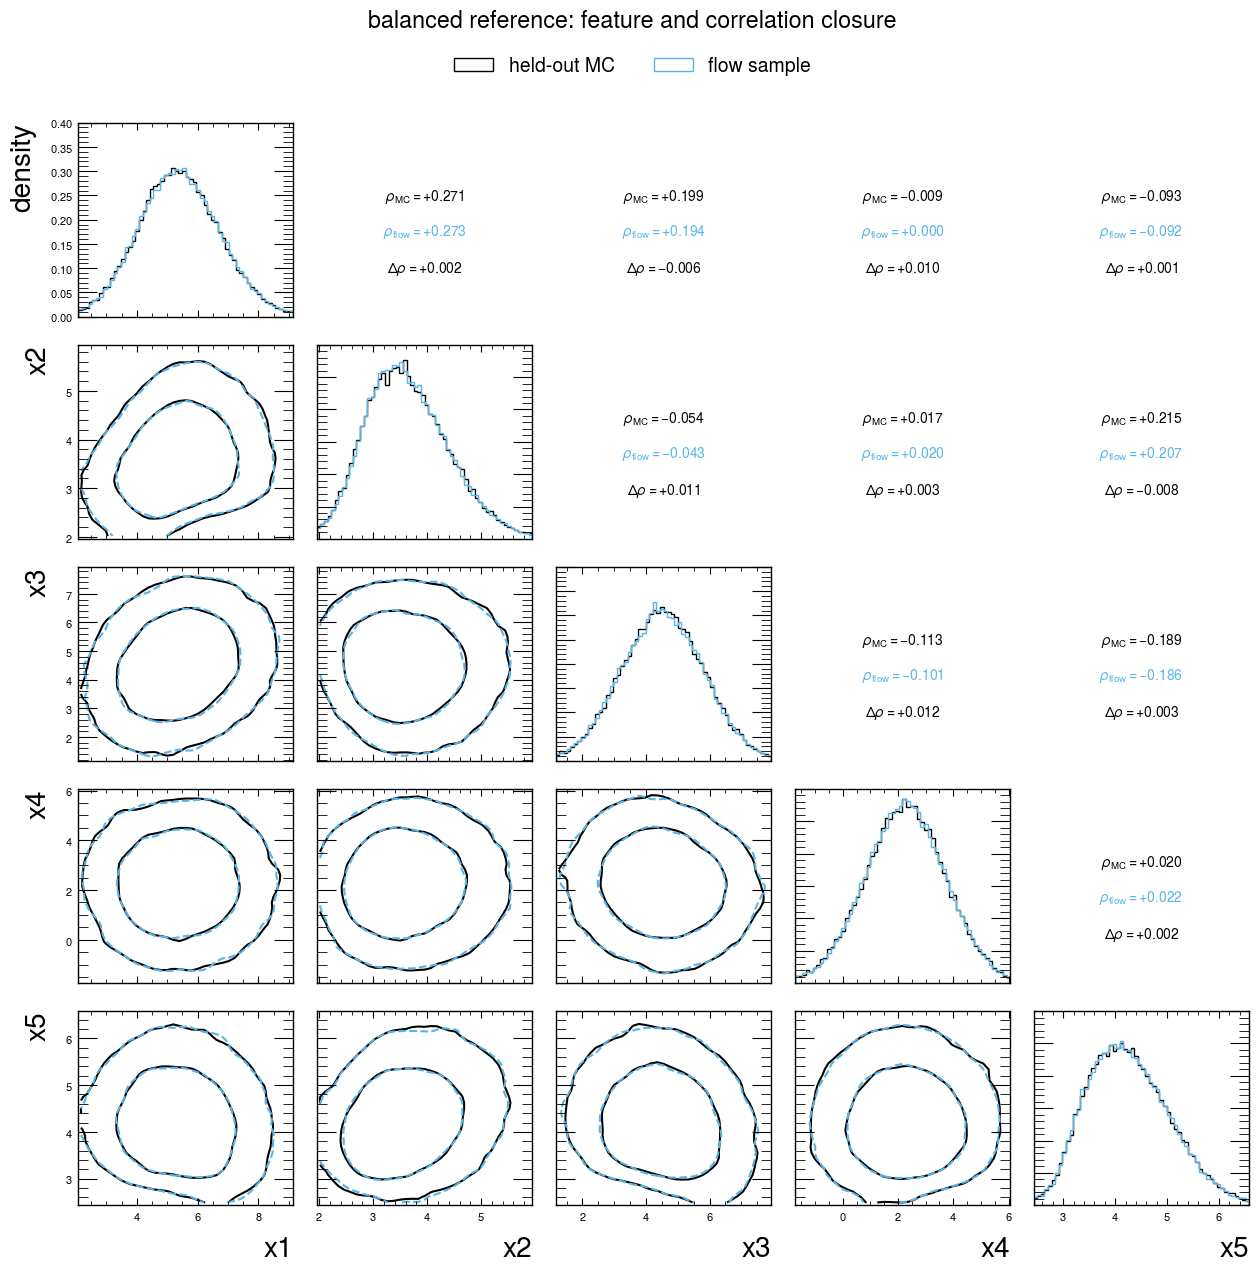

In [35]:
n_plot = min(50_000, len(reference_flow_eval), len(reference_sample))
reference_pair_mc = reference_flow_eval.sample(
    n=n_plot, random_state=SEED
)[FEATURES].to_numpy(dtype=np.float32)
reference_pair_generated = reference_sample.sample(
    n=n_plot, random_state=SEED + 1
)[FEATURES].to_numpy(dtype=np.float32)

fig = plot_flow_pair_closure(
    "balanced reference",
    reference_pair_mc,
    reference_pair_generated,
    FEATURES,
)
export_exercise5_figure(fig, "reference_feature_correlation_closure")
plt.show()


## Validation 2: closure as a function of the learned log density

The five reconstructed variables can also be compressed to the scalar learned log density

$$
\ell(x) = \log \hat p_\mathrm{flow}(x).
$$

Below, we evaluate the **trained reference flow** on two sets of events: held-out MC events and events sampled from the flow. If the learned density reproduces the data distribution, the two distributions of $\ell(x)$ should agree.

The generated reference uses many more events by default than the held-out MC points. Its finite-sampling fluctuations are therefore small, and the visible statistical uncertainty is dominated by the finite MC evaluation sample. The lower panel shows the bin-by-bin ratio $\mathrm{MC}/\mathrm{flow}$; its error bars include the finite counts in both histograms, although the high-statistics flow contribution is small. This does **not** remove uncertainty or bias in the trained flow itself; it only makes the numerical sampling of that fixed flow very precise.

### CDF-versus-CDF closure

The same comparison can be displayed as a probability–probability (P–P) plot. For common thresholds in $\ell=\log \hat p(x)$, we plot the empirical MC CDF against the flow CDF,

$$
F_\mathrm{MC}(\ell) \quad\text{versus}\quad F_\mathrm{flow}(\ell).
$$

Perfect closure therefore follows the diagonal $F_\mathrm{MC}=F_\mathrm{flow}$. The lower panel shows the ratio $F_\mathrm{MC}/F_\mathrm{flow}$; the scan starts at $F_\mathrm{flow}=10^{-3}$ to avoid division by zero. The blue bands are the approximate pointwise $\pm1\sigma$ finite-sample expectations; neighboring CDF points are correlated, and the bands do not include flow-training uncertainty.

This remains a one-dimensional projection. It is a useful and sensitive diagnostic, but agreement here alone does not prove complete five-dimensional closure because different regions of feature space can have the same value of $\log \hat p(x)$.


Wrote standalone figure script: exercise5_figures_scripts/reference_log_density_closure.py


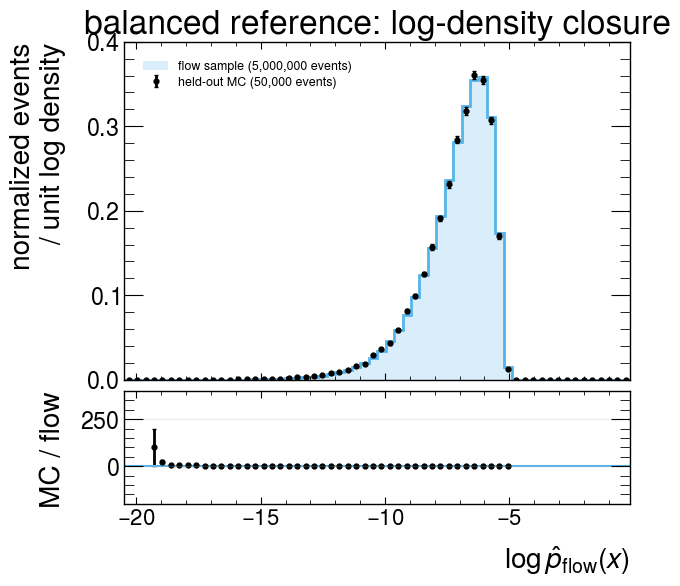

Wrote standalone figure script: exercise5_figures_scripts/reference_log_density_cdf_closure.py


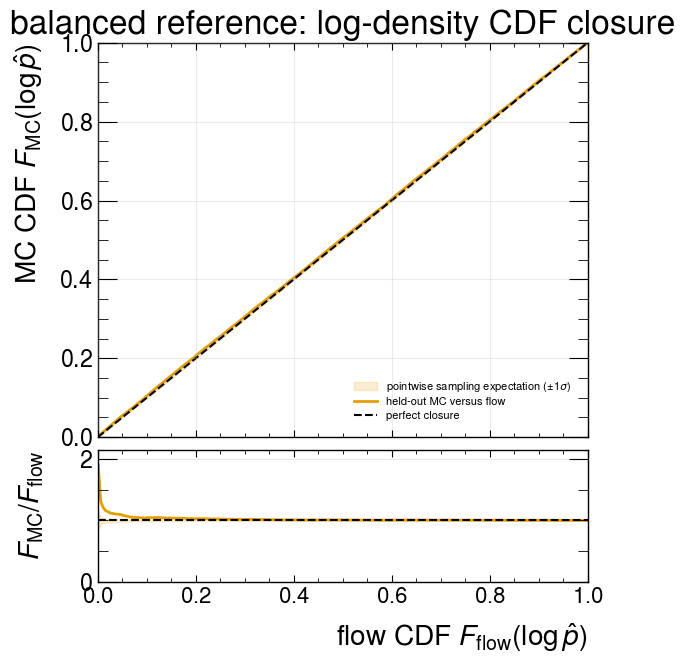

In [36]:
n_mc = min(50_000, len(reference_flow_eval))
reference_log_p_mc = reference_log_prob_x(
    reference_flow_eval.sample(n=n_mc, random_state=SEED)[FEATURES]
)
reference_log_p_generated = reference_log_prob_x(reference_sample[FEATURES])

fig = plot_log_prob_closure(
    "balanced reference", reference_log_p_mc, reference_log_p_generated
)
export_exercise5_figure(fig, "reference_log_density_closure")
plt.show()
cdf_fig = plot_log_prob_cdf_closure(
    "balanced reference",
    reference_log_p_mc,
    reference_log_p_generated,
    color="C2",
)
export_exercise5_figure(cdf_fig, "reference_log_density_cdf_closure")
plt.show()


## Validation 3: compare the reference flow with analytic truth

The smeared signal and background densities are analytically available for this toy generator. After PRESEL, the truth reference is

$$
p_{\rm ref}^{\rm truth}(x)
=\tfrac12\frac{p_S(x)}{\epsilon_S}
+\tfrac12\frac{p_B(x)}{\epsilon_B},\qquad x\in\mathrm{PRESEL}.
$$

This comparison diagnoses the reference flow itself. Later we will verify that ratio multiplication cancels residual reference-flow errors in the reconstructed signal and background densities.


In [37]:
def reco_components_from_truth_components(components):
    scale, resolution = smearing_parameters()
    scale = np.asarray(scale, dtype=float)
    resolution = np.asarray(resolution, dtype=float)
    D = np.diag(scale)
    response_cov = np.diag(resolution**2)

    reco_components = []
    for frac, mean_y, cov_y in components:
        mean_x = scale * np.asarray(mean_y, dtype=float)
        cov_x = D @ np.asarray(cov_y, dtype=float) @ D.T + response_cov
        reco_components.append((frac, mean_x, cov_x))
    return reco_components


def mixture_log_density(x, components):
    x = np.asarray(x, dtype=float)
    fracs = np.asarray([component[0] for component in components], dtype=float)
    fracs = fracs / fracs.sum()
    terms = [
        np.log(frac)
        + multivariate_normal(mean=mean, cov=cov, allow_singular=False).logpdf(x)
        for frac, (_, mean, cov) in zip(fracs, components)
    ]
    return logsumexp(np.vstack(terms), axis=0)


TRUTH_RECO_COMPONENTS = {
    "background": reco_components_from_truth_components(background_components()),
    "signal": reco_components_from_truth_components(signal_components()),
}


def selected_truth_log_density(x, sample_name):
    return (
        mixture_log_density(x, TRUTH_RECO_COMPONENTS[sample_name])
        - np.log(PRESEL_EFFICIENCY[sample_name])
    )


def reference_truth_log_density(x):
    return np.logaddexp(
        np.log(0.5) + selected_truth_log_density(x, "signal"),
        np.log(0.5) + selected_truth_log_density(x, "background"),
    )


def build_binned_log_density_calibration(log_p_truth, log_p_model, n_bins=25):
    log_p_truth = np.asarray(log_p_truth, dtype=float)
    log_p_model = np.asarray(log_p_model, dtype=float)
    delta = log_p_model - log_p_truth
    edges = np.unique(np.quantile(log_p_truth, np.linspace(0.0, 1.0, n_bins + 1)))
    eps = 1.0e-9 * max(1.0, float(edges[-1] - edges[0]))
    edges = edges.copy()
    edges[0] -= eps
    edges[-1] += eps
    index = np.clip(
        np.searchsorted(edges, log_p_truth, side="right") - 1,
        0,
        len(edges) - 2,
    )

    rows = []
    for bin_index in range(len(edges) - 1):
        mask = index == bin_index
        count = int(mask.sum())
        if count == 0:
            rows.append(
                {
                    "bin": bin_index,
                    "truth_lo": edges[bin_index],
                    "truth_hi": edges[bin_index + 1],
                    "count": 0,
                    "truth_mean": np.nan,
                    "flow_mean": np.nan,
                    "flow_sem": np.nan,
                    "delta_mean": np.nan,
                    "delta_sem": np.nan,
                }
            )
            continue
        flow_std = log_p_model[mask].std(ddof=1) if count > 1 else 0.0
        delta_std = delta[mask].std(ddof=1) if count > 1 else 0.0
        rows.append(
            {
                "bin": bin_index,
                "truth_lo": edges[bin_index],
                "truth_hi": edges[bin_index + 1],
                "count": count,
                "truth_mean": log_p_truth[mask].mean(),
                "flow_mean": log_p_model[mask].mean(),
                "flow_sem": flow_std / np.sqrt(count),
                "delta_mean": delta[mask].mean(),
                "delta_sem": delta_std / np.sqrt(count),
            }
        )
    return pd.DataFrame(rows), edges


reference: corr(log p) = 0.9899, RMSE = 0.2123, bias = -0.0122
Wrote standalone figure script: exercise5_figures_scripts/reference_log_density_truth_scatter.py


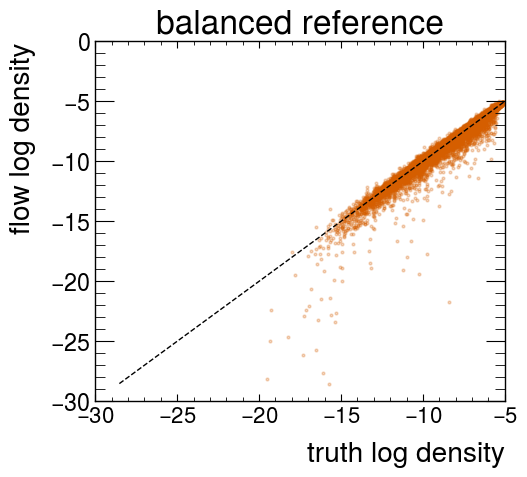

Wrote standalone figure script: exercise5_figures_scripts/reference_log_density_truth_binned.py


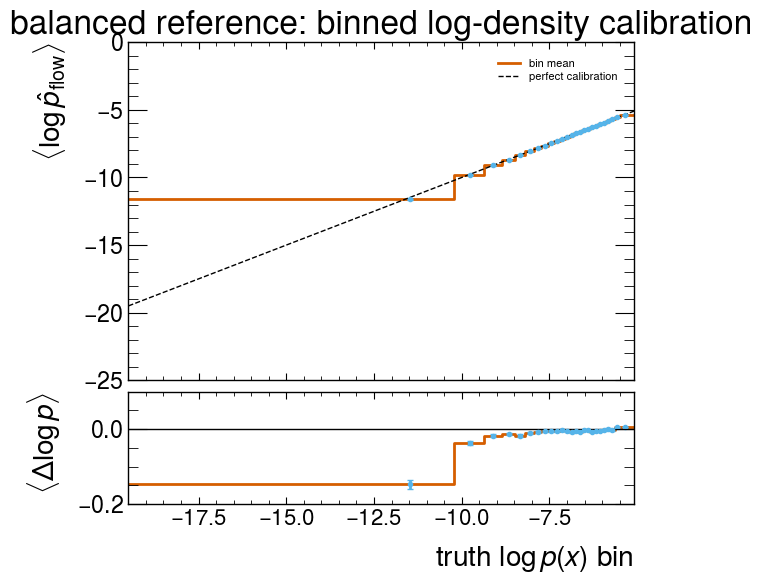

In [38]:
n_truth_validation = min(100_000, len(reference_flow_eval))
X_reference_validation = reference_flow_eval.sample(
    n=n_truth_validation, random_state=SEED
)[FEATURES].to_numpy(dtype=np.float32)
reference_log_p_truth = reference_truth_log_density(X_reference_validation)
reference_log_p_flow = reference_log_prob_x(X_reference_validation)
reference_delta = reference_log_p_flow - reference_log_p_truth

print(
    "reference: "
    f"corr(log p) = {np.corrcoef(reference_log_p_truth, reference_log_p_flow)[0, 1]:.4f}, "
    f"RMSE = {np.sqrt(np.mean(reference_delta**2)):.4f}, "
    f"bias = {reference_delta.mean():.4f}"
)
fig = plot_log_density_truth_scatter(
    "balanced reference", reference_log_p_truth, reference_log_p_flow
)
export_exercise5_figure(fig, "reference_log_density_truth_scatter")
plt.show()

reference_calibration, reference_calibration_edges = build_binned_log_density_calibration(
    reference_log_p_truth, reference_log_p_flow
)
fig = plot_log_density_truth_binned(
    "balanced reference",
    reference_calibration,
    reference_calibration_edges,
    reference_log_p_truth,
    reference_log_p_flow,
)
export_exercise5_figure(fig, "reference_log_density_truth_binned")
plt.show()


## Train $p_S/p_{\rm ref}$ and $p_B/p_{\rm ref}$

We now return to the classifier-based likelihood-ratio trick from Exercises 2.2a and 2.2b. For each target sample, the numerator events have label one and flow-sampled reference events have label zero. The total BCE weight of each class is normalized to one, so

$$
q_\psi(y=1\mid x)=\frac{p_{\rm target}(x)}{p_{\rm target}(x)+p_{\rm ref}(x)},
\qquad
r_\psi(x)=\frac{q_\psi}{1-q_\psi}
\simeq\frac{p_{\rm target}(x)}{p_{\rm ref}(x)}.
$$

The signal and background ensembles are trained sequentially to keep peak memory bounded. Each final ratio is the arithmetic mean of four independently initialized networks, exactly as in Exercise 2.3. All members share one train/holdout split, so the calibration and reweighting plots remain genuinely out of sample and validate the ensemble prediction actually used in the likelihood.


In [39]:
def build_ratio_training_dataframe(target_df, reference_df, max_events, seed):
    n_events = min(int(max_events), len(target_df), len(reference_df))
    if n_events < int(max_events):
        print(
            f"Requested {int(max_events):,} events per ratio class; "
            f"using the available {n_events:,}."
        )

    target = target_df.sample(n=n_events, random_state=seed)[FEATURES + ["weight"]].copy()
    reference = reference_df.sample(
        n=n_events, random_state=seed + 1
    )[FEATURES + ["weight"]].copy()

    target["weights"] = target["weight"]
    target["weights_normed"] = target["weight"] / target["weight"].sum()
    target["train_labels"] = 1.0
    reference["weights"] = reference["weight"]
    reference["weights_normed"] = reference["weight"] / reference["weight"].sum()
    reference["train_labels"] = 0.0

    return pd.concat([target, reference], ignore_index=True).sample(
        frac=1.0, random_state=seed + 2, ignore_index=True
    )


def as_inference_session(model_candidate):
    if isinstance(model_candidate, ort.InferenceSession):
        return model_candidate
    providers = [
        provider
        for provider in ["CUDAExecutionProvider", "CPUExecutionProvider"]
        if provider in ort.get_available_providers()
    ]
    if not providers:
        providers = ort.get_available_providers()
    options = ort.SessionOptions()
    options.intra_op_num_threads = 1
    options.inter_op_num_threads = 1
    return ort.InferenceSession(
        model_candidate.SerializeToString(),
        sess_options=options,
        providers=providers,
    )


def make_ratio_trainer(sample_name, training_dataframe):
    return density_ratio_trainer(
        dataset=training_dataframe,
        weights=training_dataframe["weights_normed"],
        training_labels=training_dataframe["train_labels"],
        features=FEATURES,
        features_scaling=FEATURES,
        sample_name=[sample_name, "reference"],
        output_name="",
        path_to_figures=f"{RATIO_PLOT_DIR[sample_name]}/",
        path_to_models=f"{RATIO_MODEL_DIR[sample_name]}/",
    )


def attach_ensemble_diagnostics(
    trainer,
    training_dataframe,
    ensemble_ratio,
    train_idx,
    holdout_idx,
):
    """Attach one common, ensemble-level train/holdout diagnostic split."""
    labels = training_dataframe["train_labels"].to_numpy()
    weights = training_dataframe["weights_normed"].to_numpy()

    trainer.train_idx = train_idx
    trainer.holdout_idx = holdout_idx
    trainer.dataset_training = training_dataframe.iloc[train_idx].copy()
    trainer.dataset_holdout = training_dataframe.iloc[holdout_idx].copy()

    labels_train = labels[train_idx]
    labels_holdout = labels[holdout_idx]
    ratio_train = ensemble_ratio[train_idx]
    ratio_holdout = ensemble_ratio[holdout_idx]
    weights_train = weights[train_idx]
    weights_holdout = weights[holdout_idx]

    trainer.ratio_den_training = ratio_train[labels_train == 0]
    trainer.ratio_num_training = ratio_train[labels_train == 1]
    trainer.weight_den_training = weights_train[labels_train == 0]
    trainer.weight_num_training = weights_train[labels_train == 1]
    trainer.ratio_den_holdout = ratio_holdout[labels_holdout == 0]
    trainer.ratio_num_holdout = ratio_holdout[labels_holdout == 1]
    trainer.weight_den_holdout = weights_holdout[labels_holdout == 0]
    trainer.weight_num_holdout = weights_holdout[labels_holdout == 1]


def train_and_validate_ratio(sample_name, target_df, seed):
    training_dataframe = build_ratio_training_dataframe(
        target_df,
        reference_sample,
        MAX_RATIO_EVENTS_PER_CLASS,
        seed,
    )
    print(
        f"Training {sample_name}/reference with "
        f"{len(training_dataframe) // 2:,} events per class and "
        f"{RATIO_ENSEMBLE_SIZE} ensemble members."
    )

    member_packs = []
    ensemble_ratio_sum = None
    common_train_idx = None
    common_holdout_idx = None

    for ensemble_index in range(RATIO_ENSEMBLE_SIZE):
        print(
            f"\n{sample_name}: ensemble member "
            f"{ensemble_index + 1}/{RATIO_ENSEMBLE_SIZE}"
        )
        # Use a common holdout split for a genuinely out-of-sample ensemble
        # validation, but change the initialization and minibatch randomness.
        np.random.seed(seed + 10_000 + ensemble_index)
        torch.manual_seed(seed + 10_000 + ensemble_index)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed + 10_000 + ensemble_index)

        trainer = make_ratio_trainer(sample_name, training_dataframe)
        trainer.train(
            hidden_layers=RATIO_HIDDEN_LAYERS,
            neurons=RATIO_NEURONS,
            number_of_epochs=RATIO_N_EPOCHS,
            batch_size=RATIO_BATCH_SIZE,
            learning_rate=RATIO_LEARNING_RATE,
            scalerType="MinMax",
            ensemble_index=ensemble_index,
            verbose=1,
            rnd_seed=seed,
            holdout_split=RATIO_HOLDOUT_FRACTION,
            validation_split=RATIO_VALIDATION_FRACTION,
            callback_patience=RATIO_PATIENCE,
            num_workers=0,
            load_trained_models=RATIO_LOAD_IF_AVAILABLE,
            calibration=False,
            type_of_calibration="histogram",
            recalibrate_output=True,
            num_bins_cal=100,
        )

        if trainer.loss_figure is not None:
            export_exercise5_figure(
                trainer.loss_figure,
                f"training_loss_{sample_name}_reference_member_{ensemble_index:02d}",
            )

        if common_train_idx is None:
            common_train_idx = trainer.train_idx.copy()
            common_holdout_idx = trainer.holdout_idx.copy()
        elif not (
            np.array_equal(common_train_idx, trainer.train_idx)
            and np.array_equal(common_holdout_idx, trainer.holdout_idx)
        ):
            raise RuntimeError("Ratio ensemble members do not share the diagnostic split.")

        member_ratio = np.asarray(trainer.full_data_ratio, dtype=np.float64)
        if not np.isfinite(member_ratio).all():
            raise FloatingPointError(
                f"Non-finite predictions from {sample_name} ensemble member "
                f"{ensemble_index}."
            )
        if ensemble_ratio_sum is None:
            ensemble_ratio_sum = member_ratio.copy()
        else:
            ensemble_ratio_sum += member_ratio

        member_packs.append(
            {
                "scaler": trainer.scaler,
                "model": as_inference_session(trainer.model_NN),
            }
        )
        del trainer, member_ratio
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    ensemble_ratio = ensemble_ratio_sum / RATIO_ENSEMBLE_SIZE
    diagnostic_trainer = make_ratio_trainer(sample_name, training_dataframe)
    attach_ensemble_diagnostics(
        diagnostic_trainer,
        training_dataframe,
        ensemble_ratio,
        common_train_idx,
        common_holdout_idx,
    )

    # Apply the familiar Exercise 2 validations to the prediction that is
    # actually used below: the arithmetic mean of all ensemble members.
    calibration_figure = diagnostic_trainer.make_calib_plots(
        observable="score", nbins=50, ensemble_index="ensemble"
    )
    export_exercise5_figure(
        calibration_figure,
        f"{sample_name}_reference_ratio_calibration",
    )

    reweighted_figures = diagnostic_trainer.make_reweighted_plots(
        FEATURES, "linear", 50, ensemble_index="ensemble"
    )
    if len(reweighted_figures) != len(FEATURES):
        raise RuntimeError("Expected one reweighting diagnostic per feature.")
    for feature, reweighted_figure in zip(FEATURES, reweighted_figures):
        export_exercise5_figure(
            reweighted_figure,
            f"{sample_name}_reference_reweighting_{feature}",
        )

    del (
        diagnostic_trainer,
        calibration_figure,
        reweighted_figures,
        reweighted_figure,
        ensemble_ratio,
        ensemble_ratio_sum,
        training_dataframe,
    )
    gc.collect()
    return member_packs


### Signal versus reference

The first classifier estimates $r_S(x)=p_S(x)/p_{\rm ref}(x)$. Its calibration plot tests the classifier-score interpretation, and its reweighting plots test whether $r_S(x)p_{\rm ref}(x)$ reproduces signal projections.


Training signal/reference with 5,000,000 events per class and 4 ensemble members.

signal: ensemble member 1/4


2026-07-16 04:41:25 | INFO | Training Logs | Reading saved models from models_Hybrid_SigvsRef_5M_ensemble4/
INFO:Training Logs:Reading saved models from models_Hybrid_SigvsRef_5M_ensemble4/
2026-07-16 05:05:28 | INFO | Training Logs | reference training data has min ratio 0.4303656136928654
INFO:Training Logs:reference training data has min ratio 0.4303656136928654
2026-07-16 05:05:28 | INFO | Training Logs | reference training data has max ratio 3.2937263060481206
INFO:Training Logs:reference training data has max ratio 3.2937263060481206
2026-07-16 05:05:28 | INFO | Training Logs | signal training data has min ratio 0.4395031225584232
INFO:Training Logs:signal training data has min ratio 0.4395031225584232
2026-07-16 05:05:28 | INFO | Training Logs | signal training data has max ratio 1000000027.2819322
INFO:Training Logs:signal training data has max ratio 1000000027.2819322
2026-07-16 05:05:28 | INFO | Training Logs | reference holdout data has min ratio 0.44404923510143524
INFO:Tra


signal: ensemble member 2/4


2026-07-16 05:05:36 | INFO | Training Logs | Reading saved models from models_Hybrid_SigvsRef_5M_ensemble4/
INFO:Training Logs:Reading saved models from models_Hybrid_SigvsRef_5M_ensemble4/
2026-07-16 05:29:33 | INFO | Training Logs | reference training data has min ratio 0.45902625752538523
INFO:Training Logs:reference training data has min ratio 0.45902625752538523
2026-07-16 05:29:33 | INFO | Training Logs | reference training data has max ratio 2.108731760501215
INFO:Training Logs:reference training data has max ratio 2.108731760501215
2026-07-16 05:29:33 | INFO | Training Logs | signal training data has min ratio 0.4484557508163269
INFO:Training Logs:signal training data has min ratio 0.4484557508163269
2026-07-16 05:29:33 | INFO | Training Logs | signal training data has max ratio 19575.681446907816
INFO:Training Logs:signal training data has max ratio 19575.681446907816
2026-07-16 05:29:33 | INFO | Training Logs | reference holdout data has min ratio 0.4602304901113458
INFO:Trai


signal: ensemble member 3/4


2026-07-16 05:29:41 | INFO | Training Logs | Reading saved models from models_Hybrid_SigvsRef_5M_ensemble4/
INFO:Training Logs:Reading saved models from models_Hybrid_SigvsRef_5M_ensemble4/
2026-07-16 05:53:59 | INFO | Training Logs | reference training data has min ratio 0.4415815966610248
INFO:Training Logs:reference training data has min ratio 0.4415815966610248
2026-07-16 05:53:59 | INFO | Training Logs | reference training data has max ratio 2.1453743419724245
INFO:Training Logs:reference training data has max ratio 2.1453743419724245
2026-07-16 05:53:59 | INFO | Training Logs | signal training data has min ratio 0.43543877043080403
INFO:Training Logs:signal training data has min ratio 0.43543877043080403
2026-07-16 05:53:59 | INFO | Training Logs | signal training data has max ratio 11.36865595718172
INFO:Training Logs:signal training data has max ratio 11.36865595718172
2026-07-16 05:53:59 | INFO | Training Logs | reference holdout data has min ratio 0.4407121974635651
INFO:Trai


signal: ensemble member 4/4


2026-07-16 05:54:07 | INFO | Training Logs | Reading saved models from models_Hybrid_SigvsRef_5M_ensemble4/
INFO:Training Logs:Reading saved models from models_Hybrid_SigvsRef_5M_ensemble4/
2026-07-16 06:18:34 | INFO | Training Logs | reference training data has min ratio 0.42082301661309185
INFO:Training Logs:reference training data has min ratio 0.42082301661309185
2026-07-16 06:18:34 | INFO | Training Logs | reference training data has max ratio 2.0892806637126426
INFO:Training Logs:reference training data has max ratio 2.0892806637126426
2026-07-16 06:18:34 | INFO | Training Logs | signal training data has min ratio 0.43862580377154864
INFO:Training Logs:signal training data has min ratio 0.43862580377154864
2026-07-16 06:18:34 | INFO | Training Logs | signal training data has max ratio 25002.30253353204
INFO:Training Logs:signal training data has max ratio 25002.30253353204
2026-07-16 06:18:34 | INFO | Training Logs | reference holdout data has min ratio 0.4510598170236869
INFO:Tr

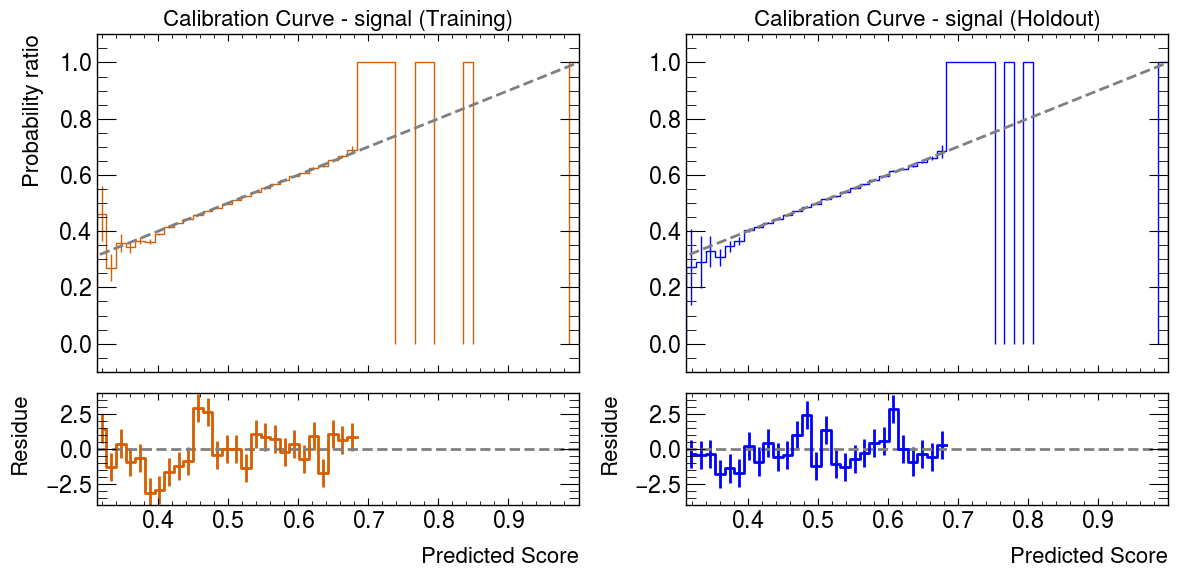

Wrote standalone figure script: exercise5_figures_scripts/signal_reference_ratio_calibration.py


/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:299: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:300: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:322: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:323: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


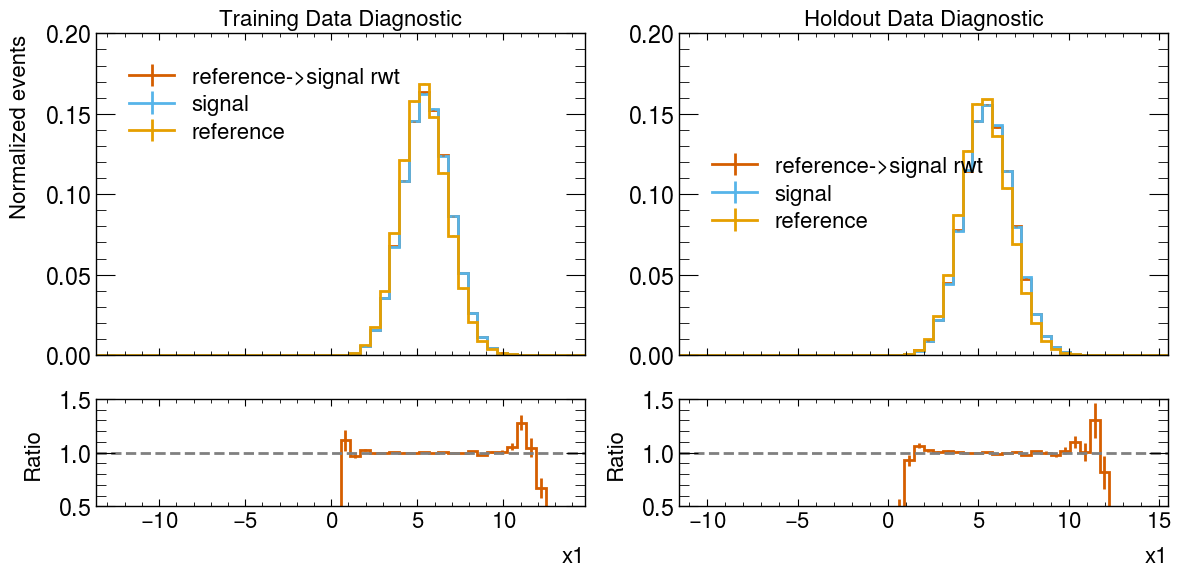

/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:299: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:300: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:322: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:323: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


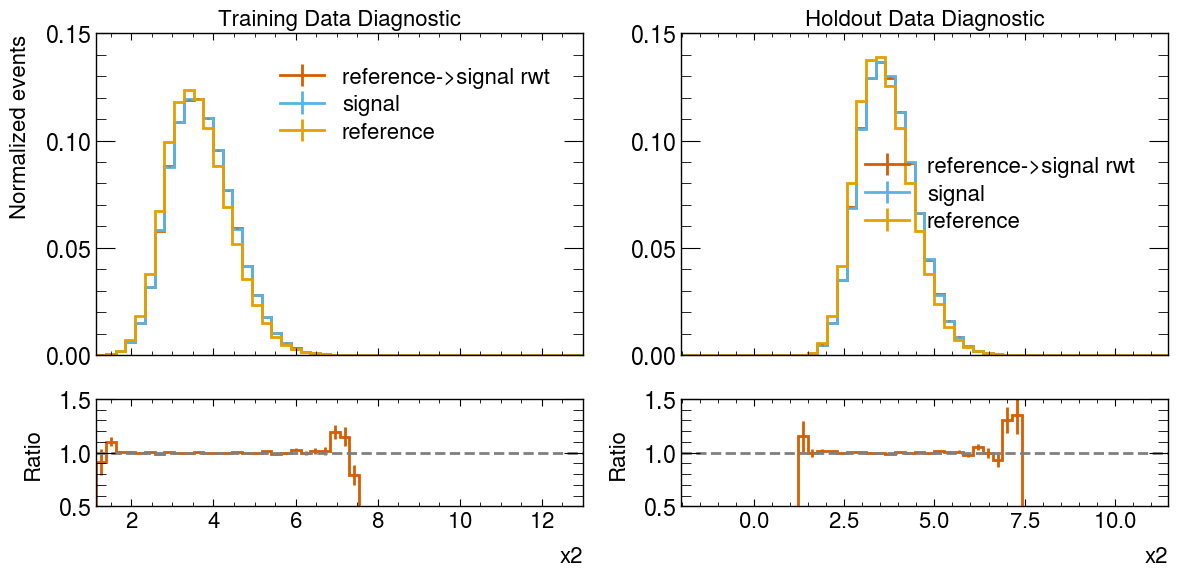

/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:299: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:299: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:300: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:322: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/p

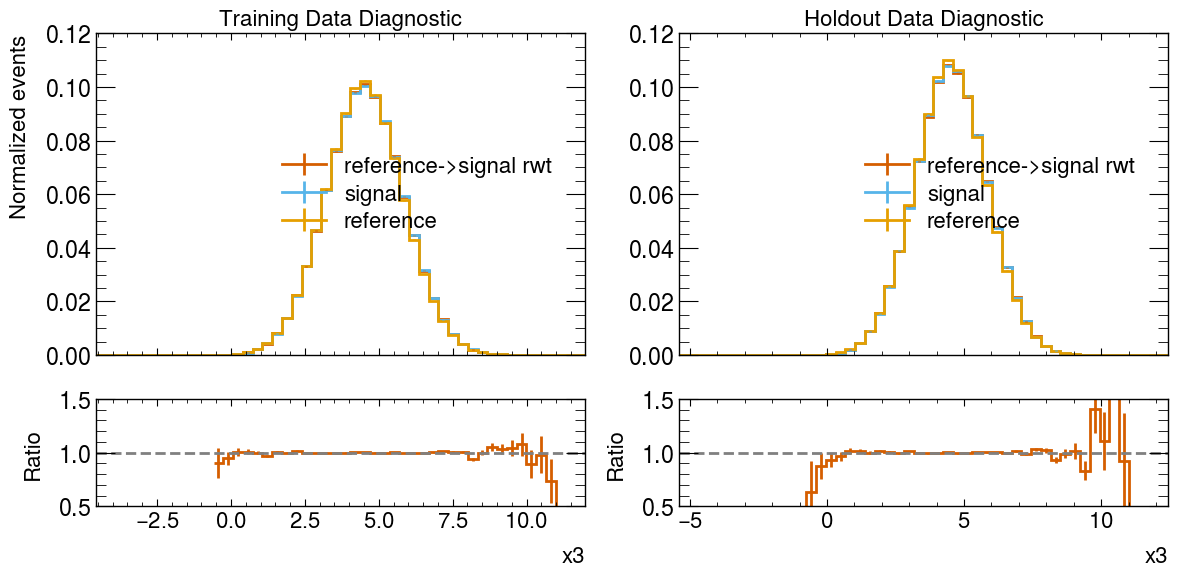

/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:300: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:323: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


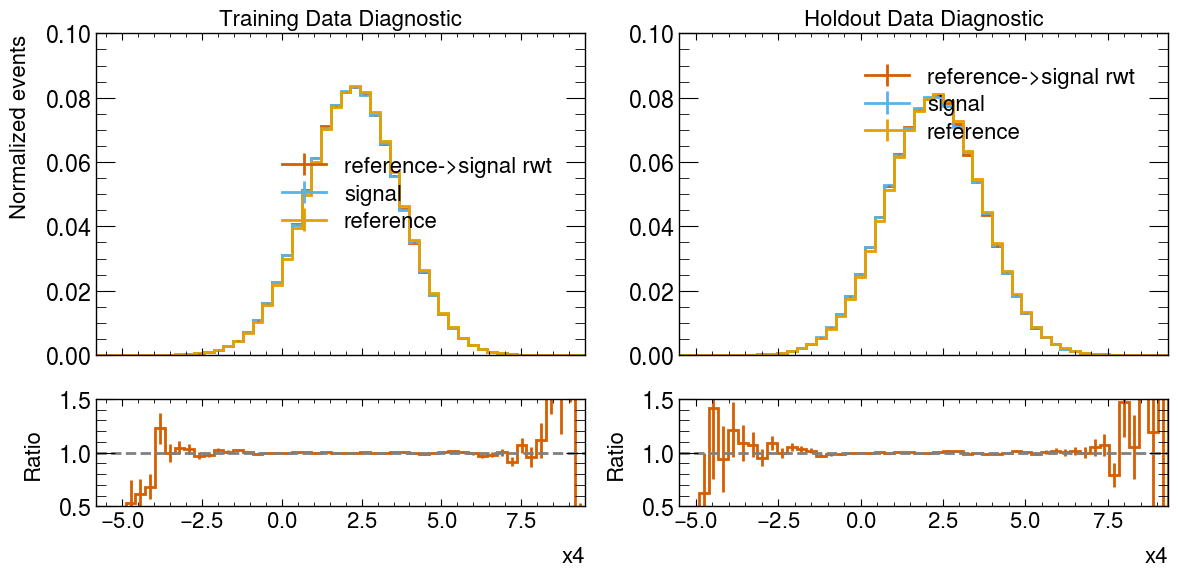

/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:299: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:300: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:322: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:323: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


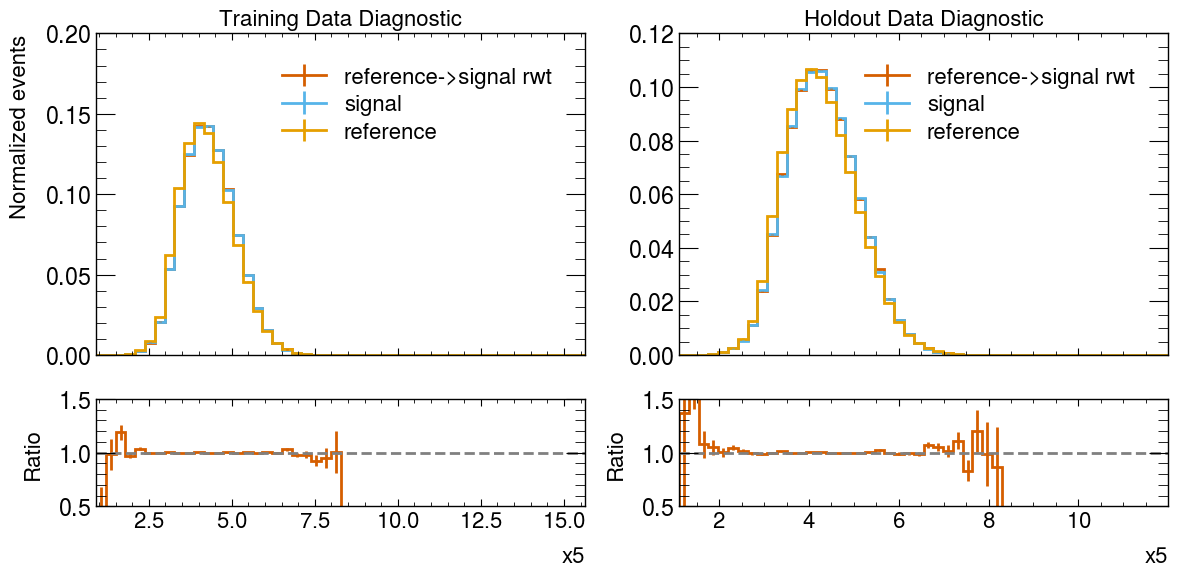

Wrote standalone figure script: exercise5_figures_scripts/signal_reference_reweighting_x1.py
Wrote standalone figure script: exercise5_figures_scripts/signal_reference_reweighting_x2.py
Wrote standalone figure script: exercise5_figures_scripts/signal_reference_reweighting_x3.py
Wrote standalone figure script: exercise5_figures_scripts/signal_reference_reweighting_x4.py
Wrote standalone figure script: exercise5_figures_scripts/signal_reference_reweighting_x5.py


28783

In [40]:
ratio_models = {}
ratio_models["signal"] = train_and_validate_ratio(
    "signal", signal_train, SEED + 601
)
del signal_train
gc.collect()


### Background versus reference

The second classifier repeats the same construction for $r_B(x)=p_B(x)/p_{\rm ref}(x)$.


Training background/reference with 5,000,000 events per class and 4 ensemble members.

background: ensemble member 1/4


2026-07-16 06:19:12 | INFO | Training Logs | Reading saved models from models_Hybrid_BkgvsRef_5M_ensemble4/
INFO:Training Logs:Reading saved models from models_Hybrid_BkgvsRef_5M_ensemble4/
2026-07-16 06:43:36 | INFO | Training Logs | reference training data has min ratio 0.17336210668974242
INFO:Training Logs:reference training data has min ratio 0.17336210668974242
2026-07-16 06:43:36 | INFO | Training Logs | reference training data has max ratio 19.15000432372186
INFO:Training Logs:reference training data has max ratio 19.15000432372186
2026-07-16 06:43:36 | INFO | Training Logs | background training data has min ratio 0.17744041420777587
INFO:Training Logs:background training data has min ratio 0.17744041420777587
2026-07-16 06:43:36 | INFO | Training Logs | background training data has max ratio 1000000027.2819322
INFO:Training Logs:background training data has max ratio 1000000027.2819322
2026-07-16 06:43:36 | INFO | Training Logs | reference holdout data has min ratio 0.17404953


background: ensemble member 2/4


2026-07-16 06:43:44 | INFO | Training Logs | Reading saved models from models_Hybrid_BkgvsRef_5M_ensemble4/
INFO:Training Logs:Reading saved models from models_Hybrid_BkgvsRef_5M_ensemble4/
2026-07-16 07:08:07 | INFO | Training Logs | reference training data has min ratio 0.1718251243419875
INFO:Training Logs:reference training data has min ratio 0.1718251243419875
2026-07-16 07:08:07 | INFO | Training Logs | reference training data has max ratio 20.99955941128956
INFO:Training Logs:reference training data has max ratio 20.99955941128956
2026-07-16 07:08:07 | INFO | Training Logs | background training data has min ratio 0.174136301493773
INFO:Training Logs:background training data has min ratio 0.174136301493773
2026-07-16 07:08:07 | INFO | Training Logs | background training data has max ratio 1000000027.2819322
INFO:Training Logs:background training data has max ratio 1000000027.2819322
2026-07-16 07:08:07 | INFO | Training Logs | reference holdout data has min ratio 0.17326716817358


background: ensemble member 3/4


2026-07-16 07:08:15 | INFO | Training Logs | Reading saved models from models_Hybrid_BkgvsRef_5M_ensemble4/
INFO:Training Logs:Reading saved models from models_Hybrid_BkgvsRef_5M_ensemble4/
2026-07-16 07:32:34 | INFO | Training Logs | reference training data has min ratio 0.1718251243419875
INFO:Training Logs:reference training data has min ratio 0.1718251243419875
2026-07-16 07:32:34 | INFO | Training Logs | reference training data has max ratio 20.99955941128956
INFO:Training Logs:reference training data has max ratio 20.99955941128956
2026-07-16 07:32:34 | INFO | Training Logs | background training data has min ratio 0.174136301493773
INFO:Training Logs:background training data has min ratio 0.174136301493773
2026-07-16 07:32:34 | INFO | Training Logs | background training data has max ratio 1000000027.2819322
INFO:Training Logs:background training data has max ratio 1000000027.2819322
2026-07-16 07:32:34 | INFO | Training Logs | reference holdout data has min ratio 0.17326716817358


background: ensemble member 4/4


2026-07-16 07:32:42 | INFO | Training Logs | Reading saved models from models_Hybrid_BkgvsRef_5M_ensemble4/
INFO:Training Logs:Reading saved models from models_Hybrid_BkgvsRef_5M_ensemble4/
2026-07-16 07:57:07 | INFO | Training Logs | reference training data has min ratio 0.1718251243419875
INFO:Training Logs:reference training data has min ratio 0.1718251243419875
2026-07-16 07:57:07 | INFO | Training Logs | reference training data has max ratio 20.99955941128956
INFO:Training Logs:reference training data has max ratio 20.99955941128956
2026-07-16 07:57:07 | INFO | Training Logs | background training data has min ratio 0.174136301493773
INFO:Training Logs:background training data has min ratio 0.174136301493773
2026-07-16 07:57:07 | INFO | Training Logs | background training data has max ratio 1000000027.2819322
INFO:Training Logs:background training data has max ratio 1000000027.2819322
2026-07-16 07:57:07 | INFO | Training Logs | reference holdout data has min ratio 0.17326716817358

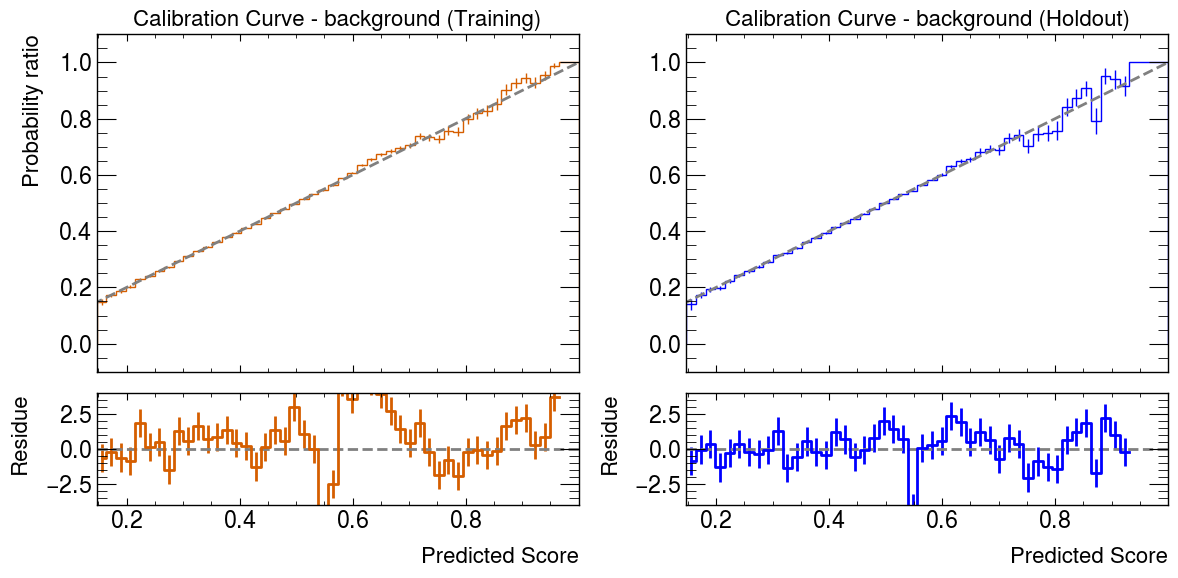

Wrote standalone figure script: exercise5_figures_scripts/background_reference_ratio_calibration.py


/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:299: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:300: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:322: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:323: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


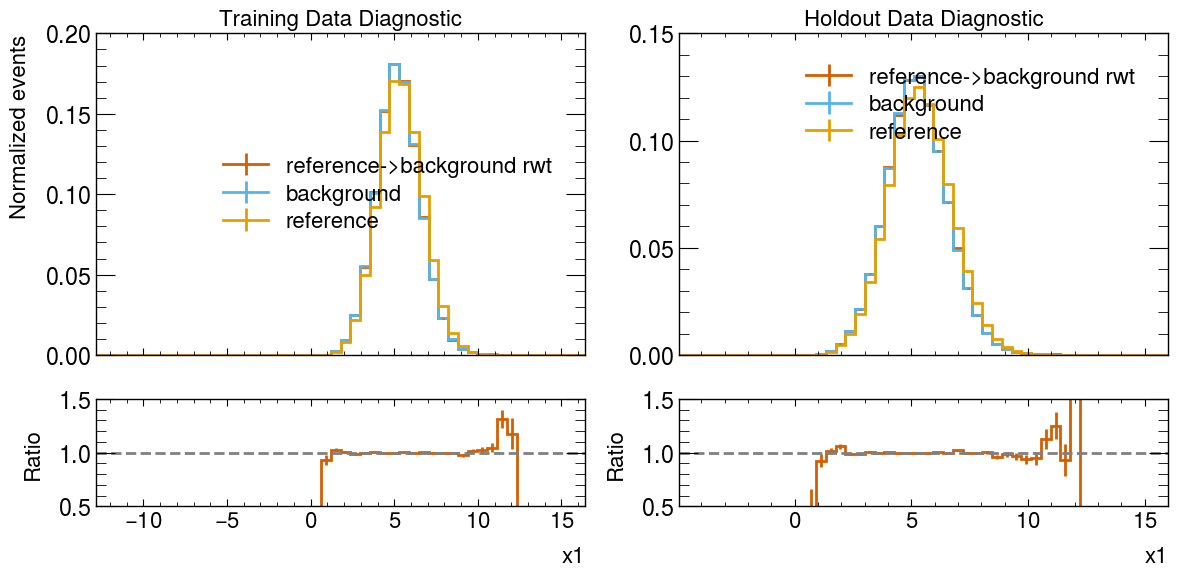

/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:299: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:300: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:322: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:323: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


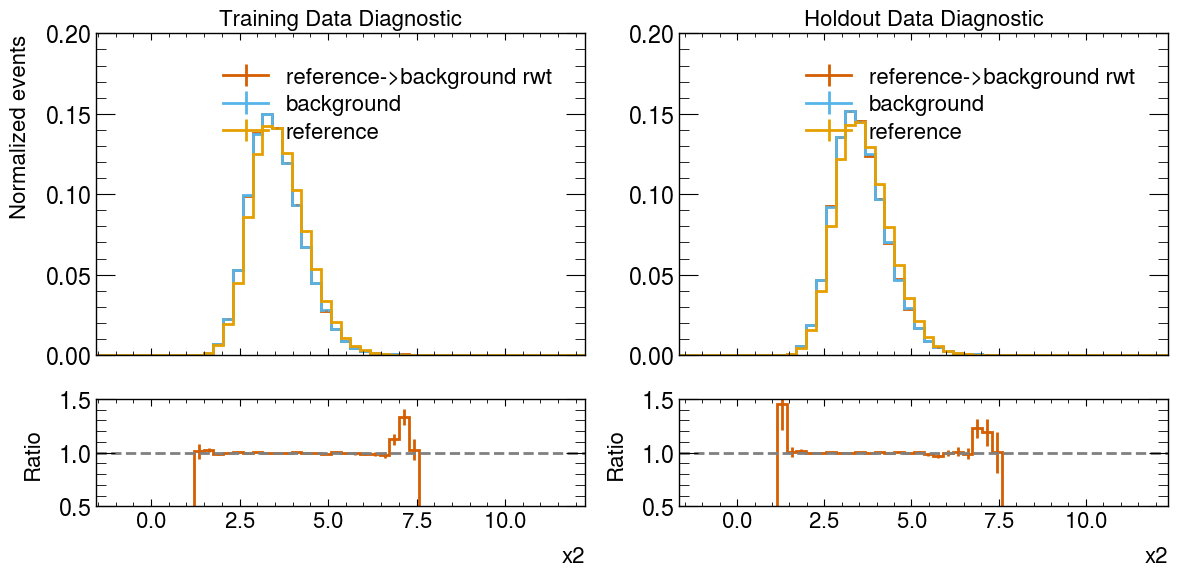

/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:299: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:300: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:322: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:323: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


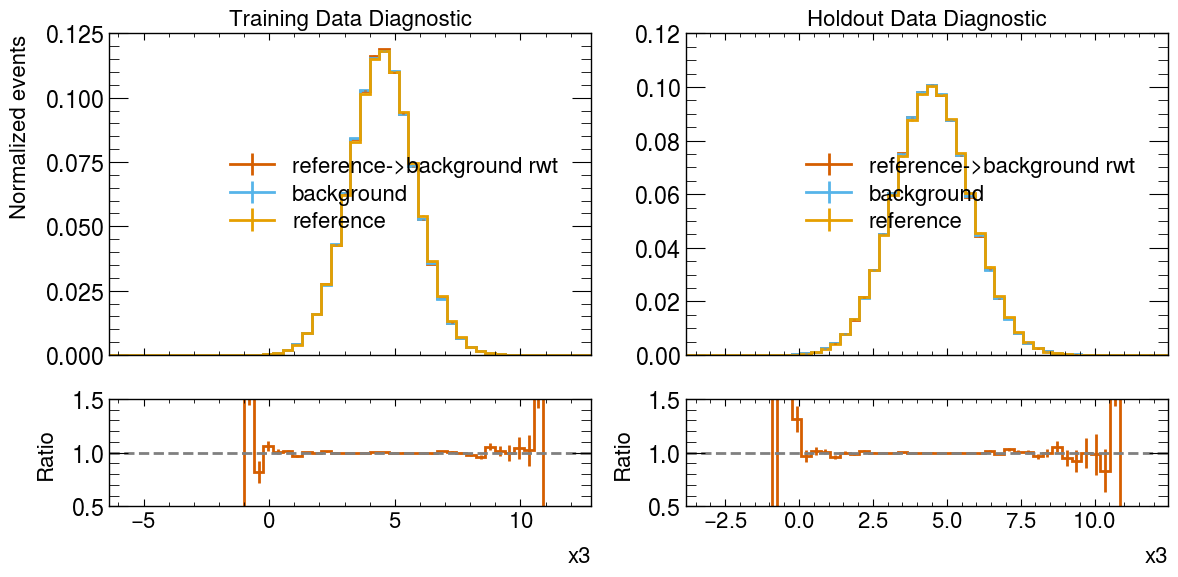

/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:299: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:300: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:323: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


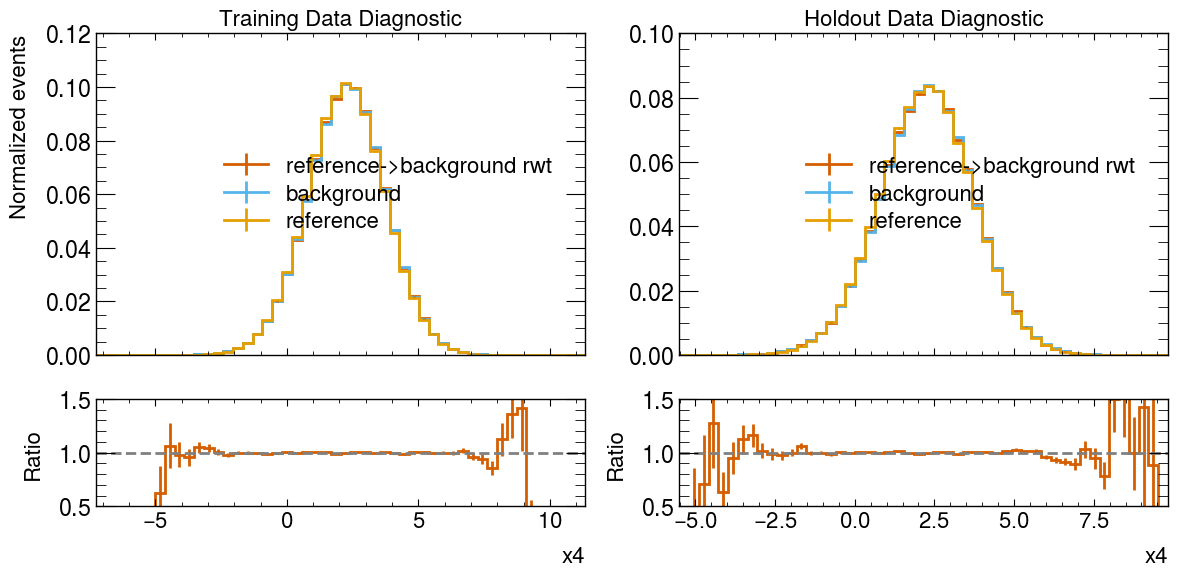

/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:299: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:300: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:322: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:323: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


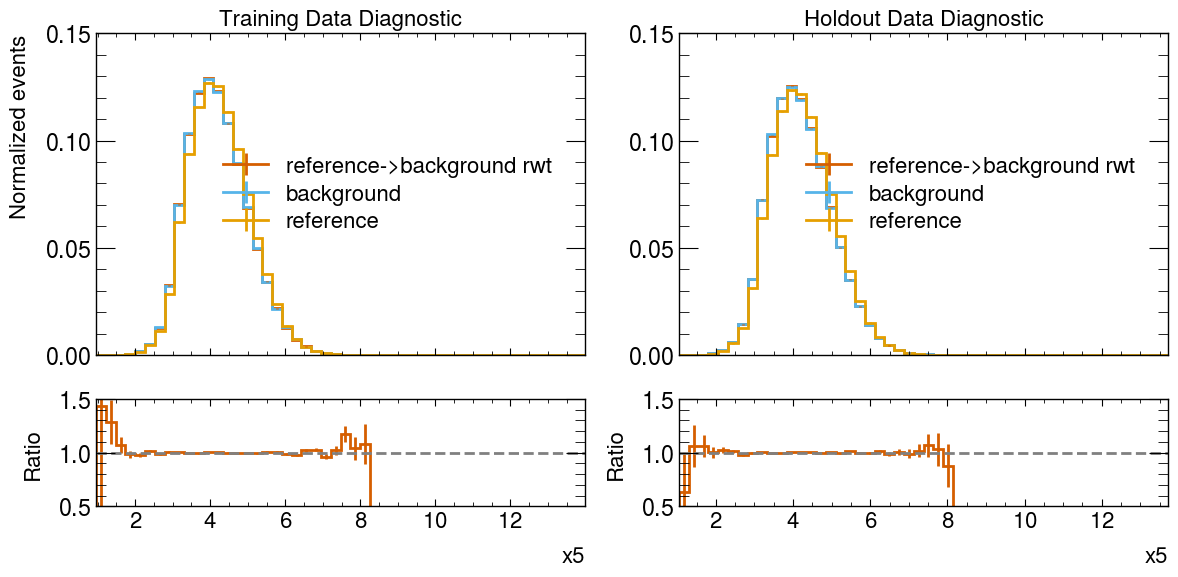

Wrote standalone figure script: exercise5_figures_scripts/background_reference_reweighting_x1.py
Wrote standalone figure script: exercise5_figures_scripts/background_reference_reweighting_x2.py
Wrote standalone figure script: exercise5_figures_scripts/background_reference_reweighting_x3.py
Wrote standalone figure script: exercise5_figures_scripts/background_reference_reweighting_x4.py
Wrote standalone figure script: exercise5_figures_scripts/background_reference_reweighting_x5.py


In [41]:
ratio_models["background"] = train_and_validate_ratio(
    "background", background_train, SEED + 701
)
del background_train
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


## Normalize the ratios and construct weighted signal/background samples

For an exact density ratio,

$$
\mathbb E_{x\sim p_{\rm ref}}[r_S(x)]
=\mathbb E_{x\sim p_{\rm ref}}[r_B(x)]=1.
$$

The five-million-event reference sample lets us impose this normalization very precisely. We divide each predicted ratio by its reference-sample mean. The resulting per-event weights

$$w_i^S=\frac{r_S(x_i)}{N_{\rm ref}},\qquad
w_i^B=\frac{r_B(x_i)}{N_{\rm ref}}$$

sum to one and turn the same unweighted reference events into weighted signal or background samples.


In [42]:
def evaluate_ratio(sample_name, dataframe, batch_size=100_000):
    packs = ratio_models[sample_name]
    chunks = []
    for start in range(0, len(dataframe), int(batch_size)):
        batch = dataframe.iloc[start : start + int(batch_size)][FEATURES]
        member_predictions = []
        for pack in packs:
            ratio = predict_with_model(
                batch.astype("float32", copy=False),
                scaler=pack["scaler"],
                model=pack["model"],
            )
            member_predictions.append(
                np.asarray(ratio, dtype=np.float64).reshape(-1)
            )

        # Exercise 2.3 uses the arithmetic mean of the member ratios.
        chunks.append(np.mean(np.stack(member_predictions, axis=0), axis=0))

    values = np.concatenate(chunks) if chunks else np.empty(0, dtype=np.float64)
    if not np.isfinite(values).all():
        raise FloatingPointError(f"The {sample_name} ratio ensemble returned NaN/inf.")
    return np.maximum(values, RATIO_FLOOR)


RATIO_NORMALIZATION = {}
for sample_name in ["signal", "background"]:
    raw_ratio = evaluate_ratio(
        sample_name,
        reference_sample,
        batch_size=RATIO_EVALUATION_BATCH_SIZE,
    )
    RATIO_NORMALIZATION[sample_name] = float(raw_ratio.mean())
    normalized_ratio = raw_ratio / RATIO_NORMALIZATION[sample_name]
    reference_sample[f"ratio_{sample_name}"] = normalized_ratio
    reference_sample[f"weight_{sample_name}"] = normalized_ratio / len(reference_sample)
    component_weights = reference_sample[f"weight_{sample_name}"].to_numpy()
    effective_sample_size = 1.0 / np.sum(component_weights**2)
    ratio_quantiles = np.quantile(normalized_ratio, [0.001, 0.5, 0.999])

    print(
        f"{sample_name:10s}: raw E_ref[r] = {RATIO_NORMALIZATION[sample_name]:.6f}; "
        f"normalized weighted yield = "
        f"{reference_sample[f'weight_{sample_name}'].sum():.6f}; "
        f"ESS = {effective_sample_size:,.0f}/{len(reference_sample):,}; "
        f"ratio q(0.1%,50%,99.9%) = {ratio_quantiles}"
    )


signal    : raw E_ref[r] = 0.999149; normalized weighted yield = 1.000000; ESS = 4,777,306/5,000,000; ratio q(0.1%,50%,99.9%) = [0.65139582 0.94568672 1.92187135]
background: raw E_ref[r] = 0.999138; normalized weighted yield = 1.000000; ESS = 4,744,565/5,000,000; ratio q(0.1%,50%,99.9%) = [0.22130897 1.03318389 2.05227737]


Wrote standalone figure script: exercise5_figures_scripts/weighted_reference_signal_background_closure.py


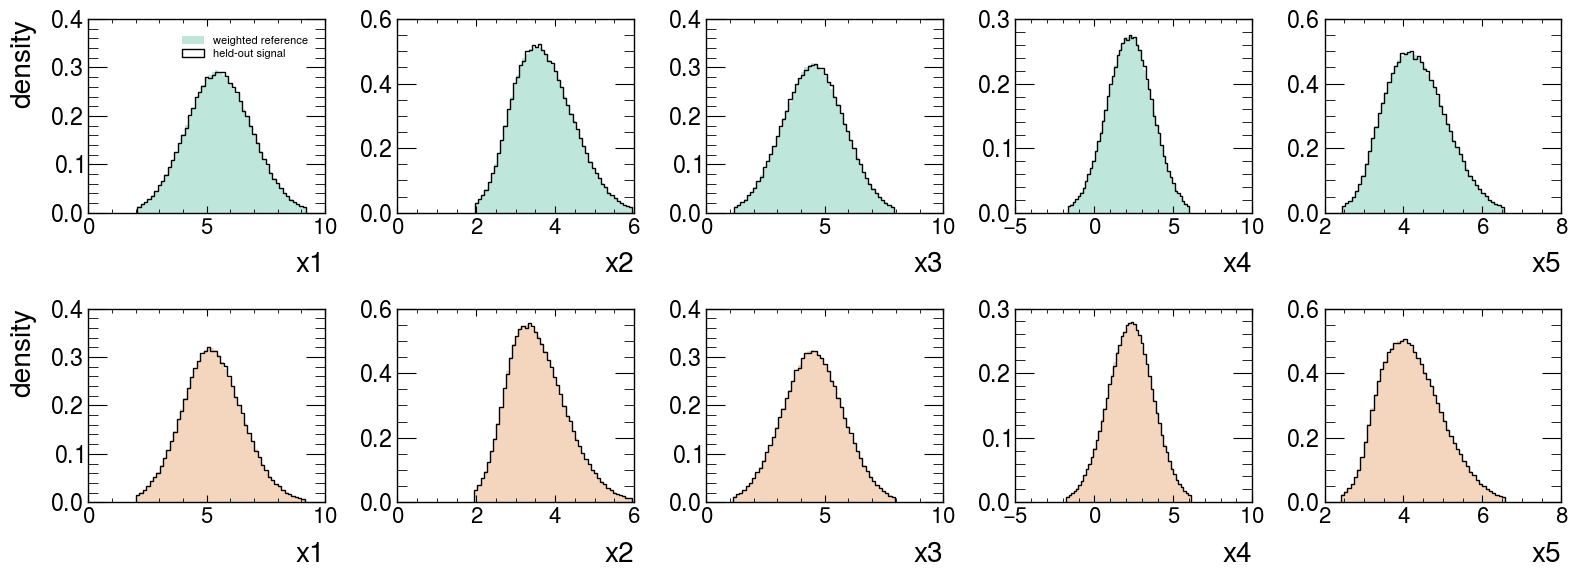

In [43]:
def plot_weighted_reference_closure(reference_df, signal_df, background_df, bins=50):
    fig, axes = plt.subplots(2, len(FEATURES), figsize=(3.2 * len(FEATURES), 6.0))
    comparisons = [
        ("signal", signal_df, "C4"),
        ("background", background_df, "C0"),
    ]
    for row, (sample_name, target_df, color) in enumerate(comparisons):
        for column, feature in enumerate(FEATURES):
            ax = axes[row, column]
            lo = min(target_df[feature].quantile(0.005), reference_df[feature].quantile(0.005))
            hi = max(target_df[feature].quantile(0.995), reference_df[feature].quantile(0.995))
            edges = np.linspace(lo, hi, bins + 1)
            ax.hist(
                reference_df[feature],
                bins=edges,
                weights=reference_df[f"weight_{sample_name}"],
                density=True,
                histtype="stepfilled",
                alpha=0.25,
                color=color,
                label="weighted reference",
            )
            ax.hist(
                target_df[feature],
                bins=edges,
                weights=target_df["weight"],
                density=True,
                histtype="step",
                lw=1.5,
                color="black",
                label=f"held-out {sample_name}",
            )
            ax.set_xlabel(feature)
            if column == 0:
                ax.set_ylabel("density")
            if row == 0 and column == 0:
                ax.legend(fontsize=8)
    fig.tight_layout()
    return fig


fig = plot_weighted_reference_closure(
    reference_sample,
    signal_eval,
    background_eval,
)
export_exercise5_figure(fig, "weighted_reference_signal_background_closure")
plt.show()


## Reconstruct and validate the hybrid densities

For any selected event we now evaluate

$$
\log\hat p_S(x)=\log\hat p_{\rm ref}(x)+\log\hat r_S(x),
\qquad
\log\hat p_B(x)=\log\hat p_{\rm ref}(x)+\log\hat r_B(x).
$$

The same reference-flow error appears in both components. The ratio networks are trained against that very reference and can therefore correct its local distortions. The plots below compare the reconstructed densities with the analytic post-selection truth.


background: corr(log p) = 0.9848, RMSE = 0.2759, bias = -0.0118
Wrote standalone figure script: exercise5_figures_scripts/hybrid_background_log_density_truth_scatter.py


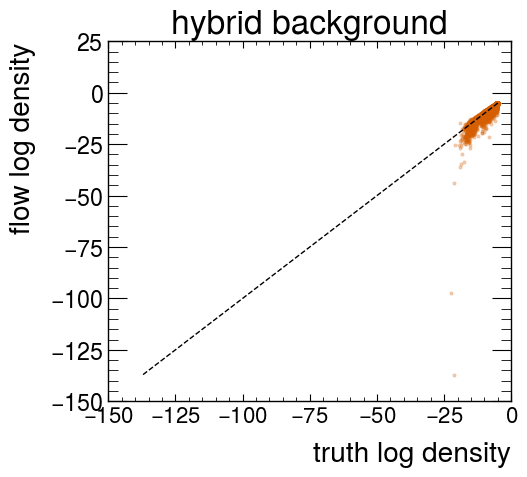

Wrote standalone figure script: exercise5_figures_scripts/hybrid_background_log_density_truth_binned.py


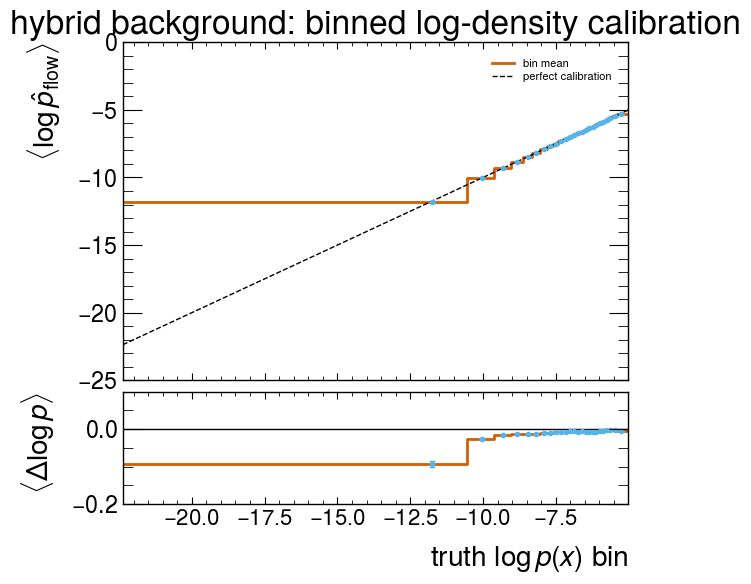

signal    : corr(log p) = 0.9810, RMSE = 0.2889, bias = -0.0120
Wrote standalone figure script: exercise5_figures_scripts/hybrid_signal_log_density_truth_scatter.py


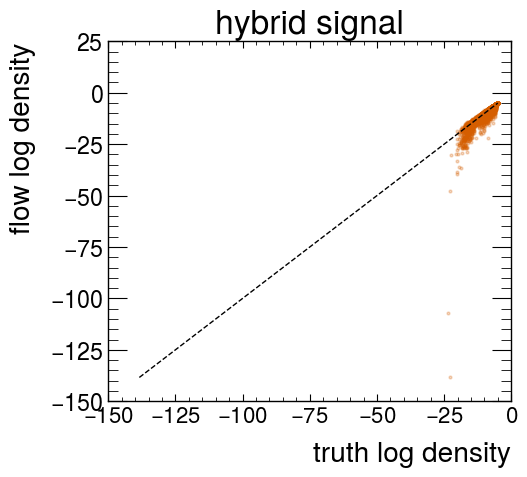

Wrote standalone figure script: exercise5_figures_scripts/hybrid_signal_log_density_truth_binned.py


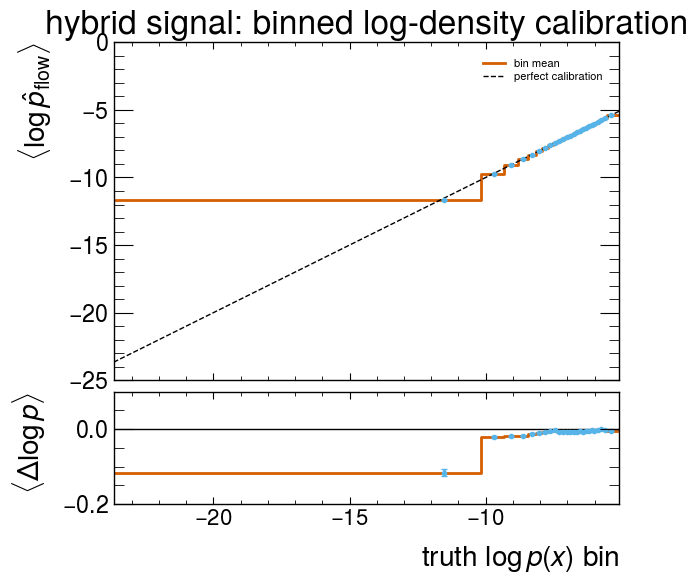

In [44]:
asimov_dataset = pd.concat(
    [background_eval, signal_eval], ignore_index=True
).copy()
weights_asimov = asimov_dataset["weight"].to_numpy(dtype=np.float64)
X_asimov = asimov_dataset[FEATURES].to_numpy(dtype=np.float32)

lam_sig = float(TOTAL_YIELD["signal"])
lam_bkg = float(TOTAL_YIELD["background"])

log_p_ref_asimov = reference_log_prob_x(X_asimov)
HYBRID_RATIOS = {}
HYBRID_LOG_DENSITIES = {}
for sample_name in ["signal", "background"]:
    ratio = evaluate_ratio(
        sample_name,
        asimov_dataset,
        batch_size=RATIO_EVALUATION_BATCH_SIZE,
    ) / RATIO_NORMALIZATION[sample_name]
    HYBRID_RATIOS[sample_name] = ratio
    HYBRID_LOG_DENSITIES[sample_name] = log_p_ref_asimov + np.log(ratio)

TRUTH_LOG_DENSITIES = {
    "signal": selected_truth_log_density(X_asimov, "signal"),
    "background": selected_truth_log_density(X_asimov, "background"),
}

for sample_name in ["background", "signal"]:
    delta = HYBRID_LOG_DENSITIES[sample_name] - TRUTH_LOG_DENSITIES[sample_name]
    print(
        f"{sample_name:10s}: corr(log p) = "
        f"{np.corrcoef(TRUTH_LOG_DENSITIES[sample_name], HYBRID_LOG_DENSITIES[sample_name])[0, 1]:.4f}, "
        f"RMSE = {np.sqrt(np.mean(delta**2)):.4f}, bias = {delta.mean():.4f}"
    )
    fig = plot_log_density_truth_scatter(
        f"hybrid {sample_name}",
        TRUTH_LOG_DENSITIES[sample_name],
        HYBRID_LOG_DENSITIES[sample_name],
    )
    export_exercise5_figure(
        fig,
        f"hybrid_{sample_name}_log_density_truth_scatter",
    )
    plt.show()

    calibration, edges = build_binned_log_density_calibration(
        TRUTH_LOG_DENSITIES[sample_name], HYBRID_LOG_DENSITIES[sample_name]
    )
    fig = plot_log_density_truth_binned(
        f"hybrid {sample_name}",
        calibration,
        edges,
        TRUTH_LOG_DENSITIES[sample_name],
        HYBRID_LOG_DENSITIES[sample_name],
    )
    export_exercise5_figure(
        fig,
        f"hybrid_{sample_name}_log_density_truth_binned",
    )
    plt.show()

np.save(HYBRID_DENSITY_DIR / "weights_asimov.npy", weights_asimov)
np.save(HYBRID_DENSITY_DIR / "log_p_ref_asimov.npy", log_p_ref_asimov)
np.save(HYBRID_DENSITY_DIR / "ratio_signal_asimov.npy", HYBRID_RATIOS["signal"])
np.save(HYBRID_DENSITY_DIR / "ratio_background_asimov.npy", HYBRID_RATIOS["background"])


## Extended likelihood from the hybrid densities

Using post-selection yields, the event intensity is

$$
\nu(x\mid\mu)=
\mu\lambda_S\hat p_{\rm ref}(x)\hat r_S(x)
+\lambda_B\hat p_{\rm ref}(x)\hat r_B(x).
$$

We deliberately evaluate the full hybrid densities in log space, exactly as in Exercise 4:

$$
-2\log L(\mu)=
-2\sum_i w_i\log\nu(x_i\mid\mu)
+2(\mu\lambda_S+\lambda_B).
$$

Factoring out $p_{\rm ref}(x_i)$ leaves a term independent of $\mu$. Consequently, the fit is controlled by the two high-precision ratios, while the explicit reference density remains available for density evaluation and event generation.


## Fit $\mu$ and construct the profile-likelihood-ratio test statistic

The normalizing flows provide the event densities, while JAX provides the likelihood gradient. Minimizing $\mathrm{NLL}=-2\log L$ gives the maximum-likelihood estimate $\hat\mu$. To test a fixed value of $\mu$, we use the **profile likelihood ratio**

$$
t_\mu = -2\log\lambda(\mu)
= -2\log\frac{L(\mu,\hat{\hat{\boldsymbol\theta}}_\mu)}{L(\hat\mu,\hat{\boldsymbol\theta})}
= \mathrm{NLL}(\mu,\hat{\hat{\boldsymbol\theta}}_\mu)-\mathrm{NLL}(\hat\mu,\hat{\boldsymbol\theta}).
$$

Here $\boldsymbol\theta$ denotes nuisance parameters, and $\hat{\hat{\boldsymbol\theta}}_\mu$ is their conditional best fit at fixed $\mu$. This exercise has no nuisance parameters, so the profiling is trivial. The scan below constructs the test-statistic curve $t_\mu$, whose minimum is $t_{\hat\mu}=0$.



 HYBRID FLOW + RATIO FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.176e+06                 │         Nfcn = 20, Ngrad = 1         │
│ EDM = 8.88e-07 (Goal: 0.0002)    │            time = 1.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬─────────

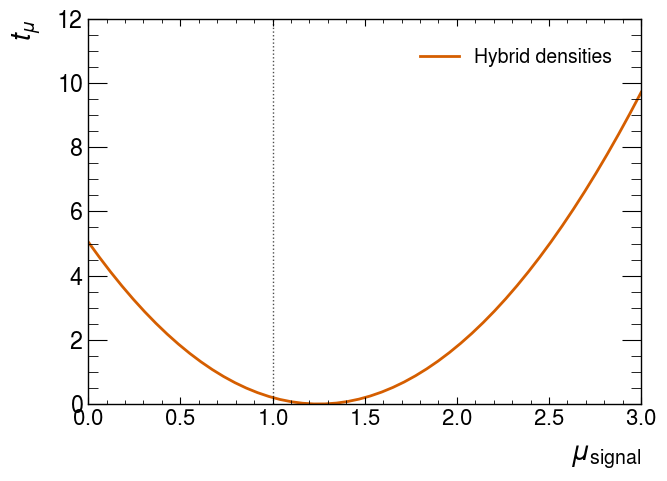

In [52]:
EPS = 1.0e-300
INVALID_NLL = 1.0e30


def make_direct_log_density_nll(
    log_p_sig_np,
    log_p_bkg_np,
    weights_np,
    lam_sig_value,
    lam_bkg_value,
):
    log_sig_intensity = jnp.asarray(
        np.log(float(lam_sig_value)) + np.asarray(log_p_sig_np, dtype=np.float64)
    )
    log_bkg_intensity = jnp.asarray(
        np.log(float(lam_bkg_value)) + np.asarray(log_p_bkg_np, dtype=np.float64)
    )
    weights_j = jnp.asarray(np.asarray(weights_np, dtype=np.float64))

    def _nll(params):
        mu = params[0]
        safe_mu = jnp.maximum(mu, EPS)
        log_event_intensity = jnp.logaddexp(
            log_bkg_intensity,
            jnp.log(safe_mu) + log_sig_intensity,
        )
        n_expected = mu * float(lam_sig_value) + float(lam_bkg_value)
        nll = -2.0 * jnp.sum(weights_j * log_event_intensity) + 2.0 * n_expected
        invalid = (mu < 0.0) | (n_expected <= 0.0) | (~jnp.isfinite(nll))
        negative_mu = jnp.minimum(mu, 0.0)
        return jnp.where(
            invalid,
            INVALID_NLL * (1.0 + negative_mu**2),
            nll,
        )

    return _nll


nll_hybrid = make_direct_log_density_nll(
    HYBRID_LOG_DENSITIES["signal"],
    HYBRID_LOG_DENSITIES["background"],
    weights_asimov,
    lam_sig,
    lam_bkg,
)
inf_hybrid = nsbi_common_utils.inference.inference(
    model_nll=jax.jit(nll_hybrid),
    initial_values=[1.0],
    list_parameters=["mu"],
    num_unconstrained_params=1,
    model_grad=jax.jit(jax.grad(nll_hybrid)),
)

print("\n" + "=" * 40)
print(" HYBRID FLOW + RATIO FIT RESULTS ")
print("=" * 40 + "\n")
inf_hybrid.perform_fit(freeze_params=[])
mu_min_hybrid = inf_hybrid.pulls_global_fit

SCAN_RANGE = (0.0, 3.0)
scan_hybrid, tmu_hybrid = inf_hybrid.perform_profile_scan(
    parameter_name="mu",
    freeze_params=[],
    bound_range=SCAN_RANGE,
    fit_strategy=0,
    size=50,
)
fig = plot_profile_scan(scan_hybrid, tmu_hybrid, label="Hybrid densities")
export_exercise5_figure(fig, "hybrid_profile_likelihood_scan")
plt.show()


### Compare with the analytic post-selection likelihood

The analytic fit uses the same weighted evaluation sample and post-selection yields. Any difference between the curves is therefore caused by the learned reference/ratio construction rather than by finite evaluation-sample fluctuations.



 ANALYTIC RECO-DENSITY FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.18e+06                  │         Nfcn = 20, Ngrad = 1         │
│ EDM = 3.09e-07 (Goal: 0.0002)    │            time = 1.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬───────

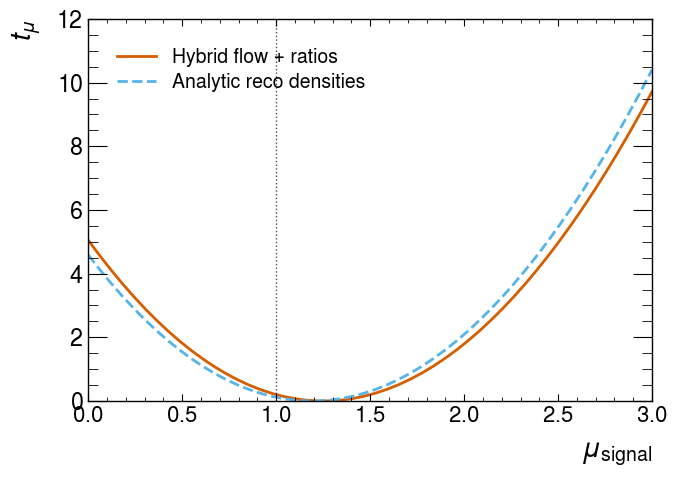

In [53]:
nll_truth = make_direct_log_density_nll(
    TRUTH_LOG_DENSITIES["signal"],
    TRUTH_LOG_DENSITIES["background"],
    weights_asimov,
    lam_sig,
    lam_bkg,
)
inf_truth = nsbi_common_utils.inference.inference(
    model_nll=jax.jit(nll_truth),
    initial_values=[1.0],
    list_parameters=["mu"],
    num_unconstrained_params=1,
    model_grad=jax.jit(jax.grad(nll_truth)),
)

print("\n" + "=" * 40)
print(" ANALYTIC RECO-DENSITY FIT RESULTS ")
print("=" * 40 + "\n")
inf_truth.perform_fit(freeze_params=[])
mu_min_truth = inf_truth.pulls_global_fit
scan_truth, tmu_truth = inf_truth.perform_profile_scan(
    parameter_name="mu",
    freeze_params=[],
    bound_range=SCAN_RANGE,
    fit_strategy=0,
    size=50,
)

mu_hat_hybrid = float(np.asarray(mu_min_hybrid).reshape(-1)[0])
mu_hat_truth = float(np.asarray(mu_min_truth).reshape(-1)[0])
print(
    f"Fitted minima: hybrid mu_hat = {mu_hat_hybrid:.6f}; "
    f"analytic mu_hat = {mu_hat_truth:.6f}; "
    f"hybrid - truth = {mu_hat_hybrid - mu_hat_truth:+.6f}"
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(scan_hybrid, tmu_hybrid, lw=2, label="Hybrid flow + ratios")
ax.plot(
    scan_truth,
    tmu_truth,
    lw=2,
    ls="--",
    label="Analytic reco densities",
)
ax.axvline(1.0, color="black", ls=":", lw=1, alpha=0.7)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"$\mu_{\rm signal}$")
ax.set_ylabel(r"$t_\mu$")
ax.legend()
fig.tight_layout()
export_exercise5_figure(fig, "hybrid_vs_analytic_profile_likelihood")
plt.show()


## A weighted unbinned Asimov dataset

The concatenated signal/background evaluation sample used above is useful for validating the learned densities against analytic truth, but it is still a finite Monte Carlo sample. We now construct a different object: an **Asimov dataset for the hybrid model itself**, at

$$
\mu_A=1.
$$

For an extended unbinned model, the data are a Poisson point process with intensity

$$
\nu(x\mid\mu)=p_{\rm ref}(x)
\left[\mu\lambda_S r_S(x)+\lambda_B r_B(x)\right].
$$

The Asimov object is most naturally the expected event measure at the chosen truth,

$$
dN_A(x)=\nu(x\mid\mu_A)\,dx,
$$

rather than a random list of integer-count events. We represent its integrals using the fixed $M$-event reference sample $x_i\sim p_{\rm ref}$. Because `weight_signal` and `weight_background` already sum to one, the event weight assigned to reference point $i$ is

$$
w_i^A
=\frac{\mu_A\lambda_S r_S(x_i)+\lambda_B r_B(x_i)}{M}
=\mu_A\lambda_S\,w_i^S+\lambda_B\,w_i^B.
$$

Its total weight is therefore exactly the expected extended yield,

$$
\sum_i w_i^A=\mu_A\lambda_S+\lambda_B.
$$

This is deterministic once the reference sample and learned ratios are fixed. It is an exact Asimov construction for the **empirical hybrid model on this reference quadrature**; no additional event generation or Poisson fluctuation enters.


In [47]:
ASIMOV_MU_TRUE = 1.0

reference_ratio_signal = reference_sample["ratio_signal"].to_numpy(
    dtype=np.float64
)
reference_ratio_background = reference_sample["ratio_background"].to_numpy(
    dtype=np.float64
)
reference_weight_signal = reference_sample["weight_signal"].to_numpy(
    dtype=np.float64
)
reference_weight_background = reference_sample["weight_background"].to_numpy(
    dtype=np.float64
)

# This ratio is all that remains after factoring the background term out of
# the extended likelihood. It is also cached below for the toy fits.
REFERENCE_LOG_Q = (
    np.log(lam_sig / lam_bkg)
    + np.log(reference_ratio_signal)
    - np.log(reference_ratio_background)
)
REFERENCE_Q = np.exp(np.clip(REFERENCE_LOG_Q, -80.0, 80.0))

WEIGHTED_ASIMOV_WEIGHTS = (
    ASIMOV_MU_TRUE * lam_sig * reference_weight_signal
    + lam_bkg * reference_weight_background
)
ASIMOV_EXPECTED_YIELD = ASIMOV_MU_TRUE * lam_sig + lam_bkg

print(f"Reference points: {len(reference_sample):,}")
print(
    f"Signal contribution to Asimov weight: "
    f"{ASIMOV_MU_TRUE * lam_sig * reference_weight_signal.sum():,.6f}"
)
print(
    f"Background contribution to Asimov weight: "
    f"{lam_bkg * reference_weight_background.sum():,.6f}"
)
print(f"Total Asimov weight: {WEIGHTED_ASIMOV_WEIGHTS.sum():,.6f}")
print(f"Expected extended yield: {ASIMOV_EXPECTED_YIELD:,.6f}")
print(
    f"Weight-sum closure: "
    f"{WEIGHTED_ASIMOV_WEIGHTS.sum() - ASIMOV_EXPECTED_YIELD:+.3e}"
)


Reference points: 5,000,000
Signal contribution to Asimov weight: 611.597726
Background contribution to Asimov weight: 152,822.479929
Total Asimov weight: 153,434.077655
Expected extended yield: 153,434.077655
Weight-sum closure: -2.037e-10


### Why this Asimov dataset must fit at $\mu_A$

Terms independent of $\mu$ can be removed from the extended NLL. With

$$
q_i=\frac{\lambda_S r_S(x_i)}{\lambda_B r_B(x_i)},
$$

the weighted Asimov objective is

$$
\widetilde{\mathrm{NLL}}_A(\mu)
=2\left[
\mu\lambda_S-\sum_i w_i^A\log(1+\mu q_i)
\right].
$$

At the generating value, each term in its score simplifies:

$$
w_i^A\frac{q_i}{1+\mu_A q_i}
=\frac{\lambda_S r_S(x_i)}{M}.
$$

The ratios were normalized on this same reference sample, so $M^{-1}\sum_i r_S(x_i)=1$. Consequently,

$$
\left.\frac{\partial\widetilde{\mathrm{NLL}}_A}{\partial\mu}
\right|_{\mu_A}
=2\left[\lambda_S-\frac{\lambda_S}{M}\sum_i r_S(x_i)\right]
=0.
$$

The second derivative is non-negative, so this stationary point is the global minimum in the physical region $\mu\geq0$. The numerical fit below is therefore a useful implementation check: a noticeable displacement from one would indicate an inconsistency in the weights, ratios, yields, or likelihood—not statistical fluctuation.


In [48]:
ASIMOV_Q_JAX = jnp.asarray(REFERENCE_Q)
ASIMOV_WEIGHTS_JAX = jnp.asarray(WEIGHTED_ASIMOV_WEIGHTS)


def weighted_asimov_relative_nll(params):
    mu = params[0]
    event_factor = 1.0 + mu * ASIMOV_Q_JAX
    n_expected = mu * lam_sig + lam_bkg
    nll = 2.0 * (
        mu * lam_sig
        - jnp.sum(
            ASIMOV_WEIGHTS_JAX
            * jnp.log(jnp.maximum(event_factor, EPS))
        )
    )
    invalid = (
        (mu < 0.0)
        | (n_expected <= 0.0)
        | jnp.any(event_factor <= 0.0)
        | (~jnp.isfinite(nll))
    )
    negative_mu = jnp.minimum(mu, 0.0)
    return jnp.where(
        invalid,
        INVALID_NLL * (1.0 + negative_mu**2),
        nll,
    )


asimov_score_at_truth = 2.0 * (
    lam_sig
    - np.sum(
        WEIGHTED_ASIMOV_WEIGHTS
        * REFERENCE_Q
        / (1.0 + ASIMOV_MU_TRUE * REFERENCE_Q)
    )
)
print(
    f"Analytic score at mu_A={ASIMOV_MU_TRUE:g}: "
    f"{asimov_score_at_truth:+.6e}"
)

inf_weighted_asimov = nsbi_common_utils.inference.inference(
    model_nll=jax.jit(weighted_asimov_relative_nll),
    initial_values=[ASIMOV_MU_TRUE],
    list_parameters=["mu"],
    num_unconstrained_params=1,
    model_grad=jax.jit(jax.grad(weighted_asimov_relative_nll)),
)

print("\n" + "=" * 40)
print(" WEIGHTED UNBINNED ASIMOV FIT ")
print("=" * 40 + "\n")
inf_weighted_asimov.perform_fit(freeze_params=[])
mu_hat_weighted_asimov = float(
    np.asarray(inf_weighted_asimov.pulls_global_fit).reshape(-1)[0]
)
asimov_fit_closes = np.isclose(
    mu_hat_weighted_asimov, ASIMOV_MU_TRUE, rtol=0.0, atol=1.0e-5
)
print(f"Asimov truth:       mu_A   = {ASIMOV_MU_TRUE:.8f}")
print(f"Asimov fitted value: muhat = {mu_hat_weighted_asimov:.8f}")
print(
    f"Closure check (|muhat-mu_A| < 1e-5): "
    f"{'PASS' if asimov_fit_closes else 'CHECK'}"
)


Analytic score at mu_A=1: +6.821210e-13

 WEIGHTED UNBINNED ASIMOV FIT 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -3.23                      │         Nfcn = 22, Ngrad = 1         │
│ EDM = 1.85e-18 (Goal: 0.0002)    │            time = 5.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───

### From the Asimov value of $q_0$ to the expected uncertainty

We now evaluate the background-only hypothesis, $\mu=0$, on an Asimov dataset generated at $\mu_A=1$. Following [Cowan, Cranmer, Gross and Vitells](https://arxiv.org/abs/1007.1727), the one-parameter Wald approximation relates the Asimov profile-likelihood ratio to the variance of the estimator:

$$
q_{0,A}
=-2\log\frac{L(0)}{L(\hat\mu_A)}
\simeq\frac{(\mu_A-0)^2}{\sigma_A^2}.
$$

Thus

$$
\sigma_A=\frac{\mu_A}{\sqrt{q_{0,A}}},
\qquad
Z_A=\sqrt{q_{0,A}}.
$$

Here $Z_A$ is the median asymptotic discovery significance for experiments generated at $\mu_A$. We call the statistic $q_0$ rather than a generic $t_0$ because the fit enforces the physical constraint $\hat\mu\geq0$: downward fluctuations that would prefer a negative signal strength are assigned $q_0=0$.

For comparison, we also compute the local curvature estimate at $\mu_A$. It uses only the immediate neighborhood of the minimum, whereas $\sigma_A$ inferred from $q_{0,A}$ summarizes the finite displacement from $\mu_A=1$ to $\mu=0$. Agreement is expected when the likelihood is close to quadratic over that interval.


In [49]:
asimov_nll_at_hat = float(
    weighted_asimov_relative_nll(jnp.asarray([mu_hat_weighted_asimov]))
)
asimov_nll_at_zero = float(
    weighted_asimov_relative_nll(jnp.asarray([0.0]))
)
ASIMOV_Q_ZERO = max(0.0, asimov_nll_at_zero - asimov_nll_at_hat)
if ASIMOV_Q_ZERO <= 0.0:
    raise RuntimeError("The mu=1 Asimov dataset did not disfavor mu=0.")

ASIMOV_Z_ZERO = np.sqrt(ASIMOV_Q_ZERO)
ASIMOV_SIGMA_MU = ASIMOV_MU_TRUE / ASIMOV_Z_ZERO
ASIMOV_INFORMATION = np.sum(
    WEIGHTED_ASIMOV_WEIGHTS
    * (
        REFERENCE_Q
        / (1.0 + ASIMOV_MU_TRUE * REFERENCE_Q)
    )**2
)
ASIMOV_SIGMA_CURVATURE = 1.0 / np.sqrt(ASIMOV_INFORMATION)

print(f"q_0,A at mu_A=1:           {ASIMOV_Q_ZERO:.6f}")
print(f"Median discovery Z_A:      {ASIMOV_Z_ZERO:.6f}")
print(f"Asimov sigma from q_0,A:   {ASIMOV_SIGMA_MU:.6f}")
print(f"Local curvature sigma:     {ASIMOV_SIGMA_CURVATURE:.6f}")
print(
    f"Relative sigma difference: "
    f"{ASIMOV_SIGMA_CURVATURE / ASIMOV_SIGMA_MU - 1.0:+.2%}"
)


q_0,A at mu_A=1:           3.229623
Median discovery Z_A:      1.797115
Asimov sigma from q_0,A:   0.556447
Local curvature sigma:     0.558017
Relative sigma difference: +0.28%


## Sampling distributions with weighted reference sampling

The fixed reference sample represents $p_{\rm ref}$. Its normalized columns `weight_signal` and `weight_background` represent $p_S$ and $p_B$. For each toy we:

1. draw independent Poisson signal and background counts;
2. sample reference-event indices with probabilities proportional to the appropriate ratio weights;
3. fit the resulting unweighted events with the same hybrid likelihood;
4. record both $t_{\mu_{\rm true}}$ and the discovery statistic $q_0$.

Only the cached ratio

$$
q_i=\frac{\lambda_S r_S(x_i)}{\lambda_B r_B(x_i)}
$$

is required by the likelihood-ratio fit. Thus the flow and neural networks are evaluated once, not once per toy. Notice the distinction between the two recorded statistics: $t_{\mu_{\rm true}}$ tests the generating value and should be approximately central, while $q_0$ tests zero and is non-central for toys generated at $\mu_{\rm true}=1$.

The first implementation below retains 1,000 exactly unbinned toys as a validation of the event-level sampler. A second implementation then compresses the one-dimensional sufficient statistic $q_i$ into a fine grid and generates 100,000 Poisson toys in batches. The compressed model is checked against the unbinned Asimov scan before it is used; this makes the much larger toy study computationally practical without reevaluating any neural network.


JAX toy padding size: 156,600 events
mu=0: completed 100/1000 toys
mu=0: completed 200/1000 toys
mu=0: completed 300/1000 toys
mu=0: completed 400/1000 toys
mu=0: completed 500/1000 toys
mu=0: completed 600/1000 toys
mu=0: completed 700/1000 toys
mu=0: completed 800/1000 toys
mu=0: completed 900/1000 toys
mu=0: completed 1000/1000 toys
mu=1: completed 100/1000 toys
mu=1: completed 200/1000 toys
mu=1: completed 300/1000 toys
mu=1: completed 400/1000 toys
mu=1: completed 500/1000 toys
mu=1: completed 600/1000 toys
mu=1: completed 700/1000 toys
mu=1: completed 800/1000 toys
mu=1: completed 900/1000 toys
mu=1: completed 1000/1000 toys
Asymptotic sigma_mu estimates: {0.0: np.float64(0.555701163476024), 1.0: np.float64(0.5580081192428089)}
           mu_hat                t_mu              q_zero              n_events            
             mean       std      mean       std      mean       std        mean         std
mu_true                                                                 

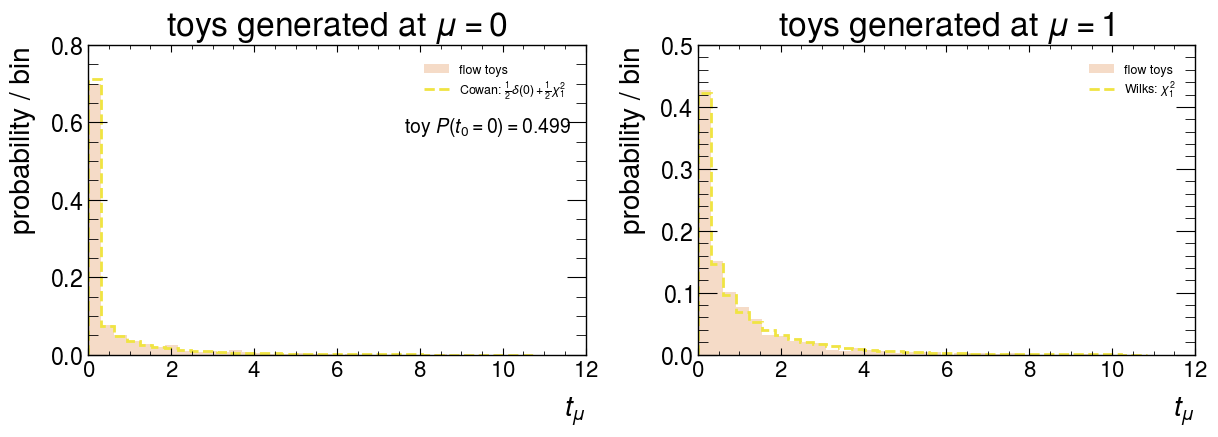

Wrote standalone figure script: exercise5_figures_scripts/toy_signal_strength_distributions.py


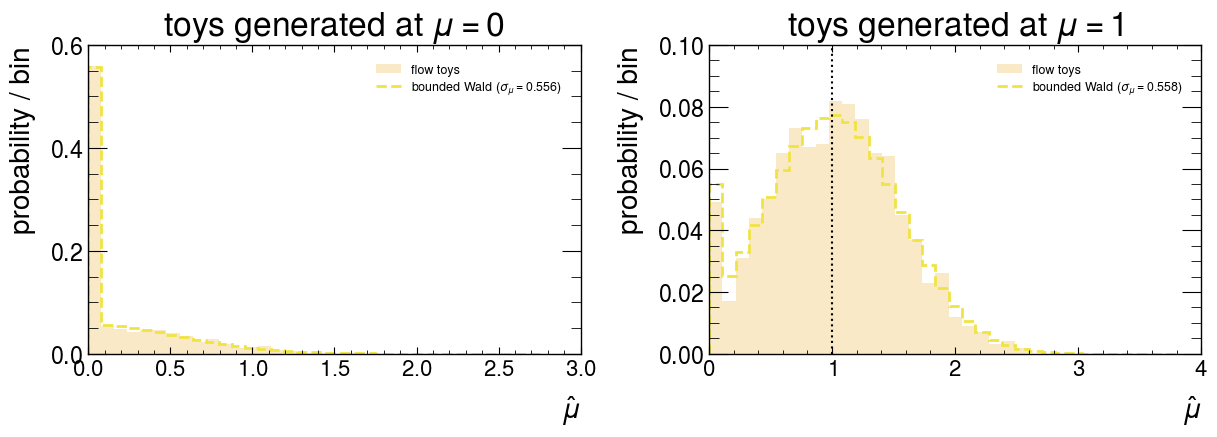

In [50]:
N_EXACT_TOYS = 1_000
TOY_HYPOTHESES = (0.0, 1.0)
TOY_SEED = 314159
TOY_PLOT_BINS = 35
TOY_VERBOSE_FITS = False
TOY_PADDING_SIGMAS = 8.0

TOY_MAX_EXPECTED_EVENTS = max(
    mu * lam_sig + lam_bkg for mu in TOY_HYPOTHESES
)
TOY_PAD_SIZE = int(
    np.ceil(
        TOY_MAX_EXPECTED_EVENTS
        + TOY_PADDING_SIGMAS * np.sqrt(TOY_MAX_EXPECTED_EVENTS)
        + 32
    )
)
print(f"JAX toy padding size: {TOY_PAD_SIZE:,} events")


def normalized_cdf(weights):
    weights = np.asarray(weights, dtype=np.float64)
    cdf = np.cumsum(weights / weights.sum())
    cdf[-1] = 1.0
    return cdf


SIGNAL_REFERENCE_CDF = normalized_cdf(reference_weight_signal)
BACKGROUND_REFERENCE_CDF = normalized_cdf(reference_weight_background)


def draw_weighted_indices(cdf, n_events, rng):
    if int(n_events) == 0:
        return np.empty(0, dtype=np.int64)
    return np.searchsorted(cdf, rng.random(int(n_events)), side="right")


def generate_hybrid_toy_q(mu_true, lam_sig_value, lam_bkg_value, rng):
    mu_true = float(mu_true)
    if mu_true < 0.0:
        raise ValueError("mu_true must be non-negative.")

    n_signal = int(rng.poisson(mu_true * lam_sig_value))
    n_background = int(rng.poisson(lam_bkg_value))
    signal_indices = draw_weighted_indices(SIGNAL_REFERENCE_CDF, n_signal, rng)
    background_indices = draw_weighted_indices(
        BACKGROUND_REFERENCE_CDF, n_background, rng
    )
    q = np.concatenate(
        [REFERENCE_Q[background_indices], REFERENCE_Q[signal_indices]]
    )
    return q, n_signal + n_background, n_signal, n_background


def _toy_relative_nll(params, q_padded, lam_sig_value, lam_bkg_value):
    mu = params[0]
    event_factor = 1.0 + mu * q_padded
    n_expected = mu * lam_sig_value + lam_bkg_value
    nll = 2.0 * (
        mu * lam_sig_value
        - jnp.sum(jnp.log(jnp.maximum(event_factor, EPS)))
    )
    invalid = (n_expected <= 0.0) | jnp.any(event_factor <= 0.0)
    return jnp.where(invalid, 1.0e30 + 1.0e12 * mu**2, nll)


TOY_NLL_KERNEL = jax.jit(_toy_relative_nll)
TOY_GRAD_KERNEL = jax.jit(jax.grad(_toy_relative_nll, argnums=0))


def hybrid_toy_test_statistic(q, test_mu, mu_hat, lam_sig_value):
    test_mu = float(test_mu)
    mu_hat = float(mu_hat)
    statistic = 2.0 * (
        (test_mu - mu_hat) * lam_sig_value
        - np.sum(np.log1p(test_mu * q) - np.log1p(mu_hat * q))
    )
    return max(0.0, float(statistic))


def fit_hybrid_toy(q, test_mu, lam_sig_value, lam_bkg_value):
    if len(q) == 0:
        t_mu = 2.0 * float(test_mu) * lam_sig_value
        return 0.0, t_mu, 0.0, 0.0
    if len(q) > TOY_PAD_SIZE:
        raise RuntimeError(
            f"Toy has {len(q):,} events, above TOY_PAD_SIZE={TOY_PAD_SIZE:,}."
        )

    q_padded = np.zeros(TOY_PAD_SIZE, dtype=np.float64)
    q_padded[: len(q)] = q
    q_jax = jnp.asarray(q_padded)

    def toy_nll(params):
        return TOY_NLL_KERNEL(params, q_jax, lam_sig_value, lam_bkg_value)

    def toy_grad(params):
        return TOY_GRAD_KERNEL(params, q_jax, lam_sig_value, lam_bkg_value)

    toy_inference = nsbi_common_utils.inference.inference(
        model_nll=toy_nll,
        initial_values=[max(0.1, float(test_mu))],
        list_parameters=["mu"],
        num_unconstrained_params=1,
        model_grad=toy_grad,
    )
    fit_output = nullcontext() if TOY_VERBOSE_FITS else redirect_stdout(StringIO())
    with fit_output:
        toy_inference.perform_fit(fit_strategy=0, freeze_params=[])
    mu_unconstrained = float(
        np.asarray(toy_inference.pulls_global_fit).reshape(-1)[0]
    )
    mu_hat = max(0.0, mu_unconstrained)

    t_mu = hybrid_toy_test_statistic(q, test_mu, mu_hat, lam_sig_value)
    q_zero = hybrid_toy_test_statistic(q, 0.0, mu_hat, lam_sig_value)
    response = q / (1.0 + float(test_mu) * q)
    observed_information = float(np.sum(response**2))
    return mu_hat, t_mu, q_zero, observed_information


def run_hybrid_toys(mu_true, n_toys, lam_sig_value, lam_bkg_value, seed):
    rng = np.random.default_rng(seed)
    rows = []
    progress_every = max(1, int(n_toys) // 10)
    for toy_index in range(int(n_toys)):
        q, n_total, n_signal, n_background = generate_hybrid_toy_q(
            mu_true, lam_sig_value, lam_bkg_value, rng
        )
        mu_hat, t_mu, q_zero, information = fit_hybrid_toy(
            q, mu_true, lam_sig_value, lam_bkg_value
        )
        rows.append(
            {
                "mu_true": float(mu_true),
                "toy": toy_index,
                "n_events": n_total,
                "n_signal": n_signal,
                "n_background": n_background,
                "mu_hat": mu_hat,
                "t_mu": t_mu,
                "q_zero": q_zero,
                "information": information,
            }
        )
        if (toy_index + 1) % progress_every == 0:
            print(f"mu={mu_true:g}: completed {toy_index + 1}/{n_toys} toys")
    return pd.DataFrame(rows)


def asymptotic_sigmas(toy_results):
    return {
        float(mu_true): 1.0 / np.sqrt(float(group["information"].mean()))
        for mu_true, group in toy_results.groupby("mu_true")
    }


toy_results = pd.concat(
    [
        run_hybrid_toys(
            mu_true,
            N_EXACT_TOYS,
            lam_sig,
            lam_bkg,
            seed=TOY_SEED + int(1000 * mu_true),
        )
        for mu_true in TOY_HYPOTHESES
    ],
    ignore_index=True,
)

sigma_by_mu = asymptotic_sigmas(toy_results)
print("Asymptotic sigma_mu estimates:", sigma_by_mu)
print(
    toy_results.groupby("mu_true")[["mu_hat", "t_mu", "q_zero", "n_events"]]
    .agg(["mean", "std"])
    .to_string()
)

fig = plot_t_mu_toys(toy_results, n_bins=TOY_PLOT_BINS)
export_exercise5_figure(fig, "toy_test_statistic_distributions")
plt.show()
fig = plot_mu_hat_toys(toy_results, sigma_by_mu, n_bins=TOY_PLOT_BINS)
export_exercise5_figure(fig, "toy_signal_strength_distributions")
plt.show()


### A computationally practical 100,000-toy study

The event likelihood depends on each event only through the scalar $q_i$. The two process distributions of $q$ can therefore be compressed into a fine one-dimensional grid. Independent Poisson counts are drawn in every grid cell, which is equivalent to drawing a Poisson total count followed by categorical events in the compressed model.

The bin likelihood ratio is constructed from the compressed signal and background probabilities themselves. The compressed model is therefore exactly normalized and internally self-consistent. Its expected $q_{0,A}$ is compared with the fully unbinned value before the large toy ensemble is generated. This is a numerical acceleration, not an asymptotic replacement for toys.


In [ ]:
N_TOYS = 100_000
TOY_Q_BINS = 512
TOY_BATCH_SIZE = 2_000
TOY_NEWTON_STEPS = 16
TOY_MU_MAX = 12.0
TOY_COMPRESSION_TAIL_QUANTILE = 1.0e-6


def build_compressed_q_model(
    q_values, signal_weights, background_weights, n_bins
):
    q_values = np.asarray(q_values, dtype=np.float64)
    log_q = np.log(np.maximum(q_values, np.finfo(np.float64).tiny))
    lower, upper = np.quantile(
        log_q,
        [TOY_COMPRESSION_TAIL_QUANTILE, 1.0 - TOY_COMPRESSION_TAIL_QUANTILE],
    )
    interior = np.linspace(lower, upper, int(n_bins) - 1)
    edges = np.concatenate(([-np.inf], interior, [np.inf]))
    signal_probability = np.histogram(
        log_q, bins=edges, weights=signal_weights
    )[0].astype(np.float64)
    background_probability = np.histogram(
        log_q, bins=edges, weights=background_weights
    )[0].astype(np.float64)

    # A negligible pseudocount keeps the finite compressed likelihood
    # defined if an extreme tail bin is populated by only one process.
    probability_floor = 1.0e-15
    signal_probability = signal_probability + probability_floor
    background_probability = background_probability + probability_floor
    signal_probability /= signal_probability.sum()
    background_probability /= background_probability.sum()
    q_binned = (
        lam_sig
        / lam_bkg
        * signal_probability
        / background_probability
    )
    return {
        "q": q_binned,
        "signal_probability": signal_probability,
        "background_probability": background_probability,
        "log_q_edges": edges,
    }


COMPRESSED_TOY_MODEL = build_compressed_q_model(
    REFERENCE_Q,
    reference_weight_signal,
    reference_weight_background,
    TOY_Q_BINS,
)
COMPRESSED_Q = COMPRESSED_TOY_MODEL["q"]
COMPRESSED_SIGNAL_PROBABILITY = COMPRESSED_TOY_MODEL["signal_probability"]
COMPRESSED_BACKGROUND_PROBABILITY = COMPRESSED_TOY_MODEL["background_probability"]


def compressed_asimov_statistic(test_mu):
    expected_counts = (
        ASIMOV_MU_TRUE * lam_sig * COMPRESSED_SIGNAL_PROBABILITY
        + lam_bkg * COMPRESSED_BACKGROUND_PROBABILITY
    )
    statistic = 2.0 * (
        (float(test_mu) - ASIMOV_MU_TRUE) * lam_sig
        - np.sum(
            expected_counts
            * (
                np.log1p(float(test_mu) * COMPRESSED_Q)
                - np.log1p(ASIMOV_MU_TRUE * COMPRESSED_Q)
            )
        )
    )
    return max(0.0, float(statistic))


COMPRESSED_ASIMOV_Q_ZERO = compressed_asimov_statistic(0.0)
compression_relative_difference = (
    COMPRESSED_ASIMOV_Q_ZERO / ASIMOV_Q_ZERO - 1.0
)
print(f"Compressed q bins: {TOY_Q_BINS:,}")
print(f"Unbinned Asimov q_0,A:   {ASIMOV_Q_ZERO:.8f}")
print(f"Compressed Asimov q_0,A: {COMPRESSED_ASIMOV_Q_ZERO:.8f}")
print(f"Relative compression difference: {compression_relative_difference:+.3%}")
if abs(compression_relative_difference) > 5.0e-3:
    raise RuntimeError(
        "The q compression changes q_0,A by more than 0.5%. "
        "Increase TOY_Q_BINS before running the large toy study."
    )


COMPRESSED_Q_JAX = jnp.asarray(COMPRESSED_Q)


@jax.jit
def fit_compressed_toy_batch(counts, test_mu):
    counts = jnp.asarray(counts, dtype=jnp.float64)
    q_values = COMPRESSED_Q_JAX
    initial_mu = jnp.clip(
        (jnp.sum(counts, axis=1) - lam_bkg) / lam_sig,
        0.0,
        TOY_MU_MAX,
    )
    score_at_zero = lam_sig - jnp.sum(counts * q_values, axis=1)

    def newton_step(_, mu):
        response = q_values / (1.0 + mu[:, None] * q_values)
        score = lam_sig - jnp.sum(counts * response, axis=1)
        information = jnp.sum(counts * response**2, axis=1)
        step = score / jnp.maximum(information, 1.0e-12)
        step = jnp.clip(step, -2.0, 2.0)
        return jnp.clip(mu - step, 0.0, TOY_MU_MAX)

    mu_hat = jax.lax.fori_loop(
        0, TOY_NEWTON_STEPS, newton_step, initial_mu
    )
    mu_hat = jnp.where(score_at_zero >= 0.0, 0.0, mu_hat)

    def statistic(mu_test):
        value = 2.0 * (
            (mu_test - mu_hat) * lam_sig
            - jnp.sum(
                counts
                * (
                    jnp.log1p(mu_test * q_values)
                    - jnp.log1p(mu_hat[:, None] * q_values)
                ),
                axis=1,
            )
        )
        return jnp.maximum(value, 0.0)

    response_at_test = q_values / (1.0 + test_mu * q_values)
    information = jnp.sum(counts * response_at_test**2, axis=1)
    fitted_response = q_values / (1.0 + mu_hat[:, None] * q_values)
    fitted_score = lam_sig - jnp.sum(counts * fitted_response, axis=1)
    fitted_score = jnp.where(mu_hat == 0.0, 0.0, fitted_score)
    return mu_hat, statistic(test_mu), statistic(0.0), information, fitted_score


def run_compressed_hybrid_toys(mu_true, n_toys, seed):
    rng = np.random.default_rng(seed)
    chunks = []
    signal_means = (
        float(mu_true) * lam_sig * COMPRESSED_SIGNAL_PROBABILITY
    )
    background_means = lam_bkg * COMPRESSED_BACKGROUND_PROBABILITY
    n_batches = int(np.ceil(int(n_toys) / TOY_BATCH_SIZE))
    for batch_index, start in enumerate(range(0, int(n_toys), TOY_BATCH_SIZE)):
        batch_size = min(TOY_BATCH_SIZE, int(n_toys) - start)
        signal_counts = rng.poisson(
            signal_means, size=(batch_size, TOY_Q_BINS)
        )
        background_counts = rng.poisson(
            background_means, size=(batch_size, TOY_Q_BINS)
        )
        total_counts = signal_counts + background_counts
        mu_hat, t_mu, q_zero, information, fitted_score = (
            fit_compressed_toy_batch(total_counts, float(mu_true))
        )
        chunks.append(
            pd.DataFrame(
                {
                    "mu_true": float(mu_true),
                    "toy": np.arange(start, start + batch_size),
                    "n_events": total_counts.sum(axis=1),
                    "n_signal": signal_counts.sum(axis=1),
                    "n_background": background_counts.sum(axis=1),
                    "mu_hat": np.asarray(mu_hat),
                    "t_mu": np.asarray(t_mu),
                    "q_zero": np.asarray(q_zero),
                    "information": np.asarray(information),
                    "fitted_score": np.asarray(fitted_score),
                }
            )
        )
        if (batch_index + 1) % max(1, n_batches // 10) == 0:
            print(
                f"mu={mu_true:g}: completed {start + batch_size:,}/{n_toys:,} toys"
            )
    return pd.concat(chunks, ignore_index=True)


toy_results = pd.concat(
    [
        run_compressed_hybrid_toys(
            mu_true, N_TOYS, seed=TOY_SEED + int(1000 * mu_true)
        )
        for mu_true in TOY_HYPOTHESES
    ],
    ignore_index=True,
)
sigma_by_mu = asymptotic_sigmas(toy_results)
print("Asymptotic sigma_mu estimates:", sigma_by_mu)
print(
    toy_results.groupby("mu_true")[["mu_hat", "t_mu", "q_zero", "n_events"]]
    .agg(["mean", "std"])
    .to_string()
)
print(
    f"Maximum interior fitted-score residual: "
    f"{toy_results['fitted_score'].abs().max():.3e}"
)

fig = plot_t_mu_toys(toy_results, n_bins=TOY_PLOT_BINS)
export_exercise5_figure(fig, "toy_test_statistic_distributions")
plt.show()
fig = plot_mu_hat_toys(toy_results, sigma_by_mu, n_bins=TOY_PLOT_BINS)
export_exercise5_figure(fig, "toy_signal_strength_distributions")
plt.show()


### Compare the Asimov prediction with pseudo-experiments

The toys provide two complementary checks of the Asimov result.

First, for $\mu_{\rm true}=1$, the Wald approximation predicts an unconstrained estimator

$$
\hat\mu_{\rm unc}\sim\mathcal N(\mu_A,\sigma_A),
$$

while the physical fit used here returns $\hat\mu=\max(0,\hat\mu_{\rm unc})$. The left panel compares that prediction with the toy distribution. We also print the toy standard deviation and RMS error about the truth; they should be close to $\sigma_A$ when the likelihood is sufficiently quadratic and the boundary is rarely reached.

Second, the Asimov result predicts the non-centrality parameter

$$
\Lambda_A=q_{0,A}=\frac{\mu_A^2}{\sigma_A^2}.
$$

For an unconstrained, two-sided $t_0$, the Wald approximation is a non-central chi-square distribution, $\chi^2_1(\Lambda_A)$. Our actual discovery statistic is one-sided. If $Y\sim\mathcal N(\sqrt{\Lambda_A},1)$, then

$$
q_0=\left[\max(0,Y)\right]^2,
$$

which has a point mass $\Phi(-\sqrt{\Lambda_A})$ at zero. The right panel shows both the boundary-aware Cowan prediction and the ordinary non-central $\chi^2$ curve. They become nearly indistinguishable when the expected significance is large, but displaying both avoids hiding the $\mu\geq0$ convention.


In [ ]:
mu_one_toys = toy_results.loc[
    toy_results["mu_true"] == ASIMOV_MU_TRUE, "mu_hat"
].to_numpy(dtype=np.float64)
q_zero_one_toys = toy_results.loc[
    toy_results["mu_true"] == ASIMOV_MU_TRUE, "q_zero"
].to_numpy(dtype=np.float64)

toy_sigma = float(np.std(mu_one_toys, ddof=1))
toy_rms_about_truth = float(
    np.sqrt(np.mean((mu_one_toys - ASIMOV_MU_TRUE)**2))
)
predicted_boundary_mass = float(norm.cdf(-ASIMOV_Z_ZERO))
observed_boundary_fraction = float(np.mean(mu_one_toys <= 1.0e-10))

print(f"Asimov sigma_mu:                    {ASIMOV_SIGMA_MU:.6f}")
print(f"Toy std(mu_hat), mu_true=1:         {toy_sigma:.6f}")
print(f"Toy RMS(mu_hat-mu_true):            {toy_rms_about_truth:.6f}")
print(
    f"Mean-information sigma from toys:   "
    f"{sigma_by_mu[ASIMOV_MU_TRUE]:.6f}"
)
print(f"Predicted P(mu_hat=0):              {predicted_boundary_mass:.4%}")
print(f"Observed toy fraction at boundary:  {observed_boundary_fraction:.4%}")


def probabilities_per_bin(values, edges):
    counts, _ = np.histogram(values, bins=edges)
    return counts / len(values)


fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

# Bounded-Gaussian prediction for the fitted signal strength.
mu_upper = max(
    float(np.max(mu_one_toys)) * 1.001,
    ASIMOV_MU_TRUE + 4.0 * ASIMOV_SIGMA_MU,
    1.25,
)
mu_edges = np.linspace(0.0, mu_upper, TOY_PLOT_BINS + 1)
mu_toy_probabilities = probabilities_per_bin(mu_one_toys, mu_edges)
mu_gaussian_cdf = norm.cdf(
    (mu_edges - ASIMOV_MU_TRUE) / ASIMOV_SIGMA_MU
)
mu_asimov_probabilities = np.diff(mu_gaussian_cdf)
# All unbounded estimates below zero are mapped to the first bin at muhat=0.
mu_asimov_probabilities[0] += mu_gaussian_cdf[0]

axes[0].stairs(
    mu_toy_probabilities,
    mu_edges,
    fill=True,
    alpha=0.35,
    color="C0",
    label=rf"Toys ($\mu_{{\rm true}}={ASIMOV_MU_TRUE:g}$)",
)
axes[0].stairs(
    mu_asimov_probabilities,
    mu_edges,
    lw=2.2,
    color="black",
    label=rf"Asimov/Wald ($\sigma_A={ASIMOV_SIGMA_MU:.3f}$)",
)
axes[0].axvline(ASIMOV_MU_TRUE, color="C3", ls=":", lw=1.5)
axes[0].set_xlabel(r"$\hat\mu$")
axes[0].set_ylabel("Probability per bin")
axes[0].set_title("Estimator width")
axes[0].legend()

# q_0 under mu_true=1: boundary-aware and ordinary non-central predictions.
noncentrality = ASIMOV_Q_ZERO
q_upper = max(
    float(np.max(q_zero_one_toys)) * 1.001,
    float(ncx2.ppf(0.999, df=1, nc=noncentrality)),
    1.0,
)
q_edges = np.linspace(0.0, q_upper, TOY_PLOT_BINS + 1)
q_toy_probabilities = probabilities_per_bin(q_zero_one_toys, q_edges)
q_ncx2_probabilities = np.diff(
    ncx2.cdf(q_edges, df=1, nc=noncentrality)
)

sqrt_lambda = np.sqrt(noncentrality)
q_boundary_cdf = norm.cdf(np.sqrt(q_edges) - sqrt_lambda)
q_boundary_probabilities = np.diff(q_boundary_cdf)
# Include the Cowan point mass at q_0=0 in the first displayed bin.
q_boundary_probabilities[0] += q_boundary_cdf[0]

axes[1].stairs(
    q_toy_probabilities,
    q_edges,
    fill=True,
    alpha=0.35,
    color="C1",
    label=rf"Toys ($\mu_{{\rm true}}={ASIMOV_MU_TRUE:g}$)",
)
axes[1].stairs(
    q_boundary_probabilities,
    q_edges,
    lw=2.2,
    color="black",
    label="Boundary-aware Cowan prediction",
)
axes[1].stairs(
    q_ncx2_probabilities,
    q_edges,
    lw=1.8,
    ls="--",
    color="C3",
    label=rf"$\chi^2_1(\Lambda_A)$, $\Lambda_A={noncentrality:.2f}$",
)
axes[1].axvline(noncentrality, color="0.4", ls=":", lw=1.2)
axes[1].set_xlabel(r"$q_0$")
axes[1].set_ylabel("Probability per bin")
axes[1].set_title(r"Discovery statistic under $\mu_{\rm true}=1$")
axes[1].legend()

fig.tight_layout()
export_exercise5_figure(fig, "asimov_prediction_vs_toys")
plt.show()


## Suggested exercises

1. Compare the hybrid fit with Exercise 4 using the same PRESEL cut and evaluation sample.
2. Toggle `USE_QUADRATIC_SPLINE` and check whether residual reference-flow differences affect the hybrid densities or cancel through the ratios.
3. Change the reference mixture away from 50:50 and study density-ratio calibration in signal-like and background-like regions.
4. Remove the explicit ratio-normalization step and measure its effect on the extended-likelihood minimum.
5. Change the density-ratio ensemble size and compare the spread of the fitted $\hat\mu$ across independently trained networks.
